# Employee Activity Tracking System
### A multi-modal computer-vision pipeline for workplace monitoring
*Graduation research notebook — Omar Khairat*

This notebook builds an end-to-end ML system that watches surveillance footage from an
office scene and produces structured **activity events** ("Employee X entered zone A at
18:19:32", "Employee Y used a phone for 43 s", "Employee X talked to Employee Y for 1 min 12 s").

The pipeline fuses **four** complementary signals to stay robust even when one of them fails:

| Stage | Purpose | Model |
|-------|---------|-------|
| Person + object detection | Find people, phones, laptops | **YOLOv8** (Ultralytics) |
| Multi-object tracking | Persistent short-term track IDs across frames | **ByteTrack** (built into Ultralytics) |
| Face recognition | Strong long-term identity when the face is visible | **InsightFace** (ArcFace) |
| Person Re-Identification (ReID) | Appearance-based identity when no face is visible | **TorchReID / OSNet** |
| Identity fusion | Stable employee ID per track, voted over time | custom temporal voting |
| Event engine | Turns identities + geometry into activity events | rule-based spatiotemporal logic |

> **Design philosophy:** We treat every track as a *probabilistic assertion* about an
> employee's identity and only commit to an `employee_id` after it wins a majority vote
> inside a rolling window. This is what lets the system recover gracefully when a person
> turns their back to the camera or walks behind an occluder.


## 0. Architecture

```
                ┌──────────────────────────────────┐
                │         video frames             │
                └───────────────┬──────────────────┘
                                │
                                ▼
                    ┌──────────────────────┐
                    │  YOLOv8 + ByteTrack  │  →  bbox, class, track_id
                    └──────────┬───────────┘
                               │ person crops
                ┌──────────────┴──────────────┐
                ▼                             ▼
        ┌───────────────┐             ┌──────────────────┐
        │ InsightFace   │             │  OSNet  (ReID)   │
        │ face embedding│             │ appearance vector│
        └───────┬───────┘             └────────┬─────────┘
                │                              │
                └───────────────┬──────────────┘
                                ▼
                 ┌──────────────────────────────┐
                 │  IdentityFuser (temporal     │
                 │  voting over gallery match)  │ →  employee_id per track
                 └──────────────┬───────────────┘
                                ▼
                 ┌──────────────────────────────┐
                 │  Event engine (zones, phone, │
                 │  proximity / interaction)    │ →  events.csv  / events.json
                 └──────────────┬───────────────┘
                                ▼
                 ┌──────────────────────────────┐
                 │ Annotated video + dashboards │
                 └──────────────────────────────┘
```

## Table of contents

1. Environment setup
2. Data exploration
3. Identity system — enrollment (face + ReID gallery)
4. Detection + tracking
5. Identity fusion
6. Activity event engine
7. End-to-end pipeline
8. Evaluation, timelines & dashboards
9. Limitations, ethics, and next steps


## 1. Environment setup

Install the heavy dependencies. The first run may take 3–5 minutes; subsequent runs are cached.

> If you are running this locally on a GPU box, install a CUDA-matched PyTorch build
> **before** running this cell (`pip install torch --index-url https://download.pytorch.org/whl/cu121`).


In [2]:
# Uncomment the first time you run the notebook.

# Step 1 — modernise the build toolchain.
# Several older packages (lap, filterpy, torchreid) ship legacy setup.py files that do
# `import pkg_resources` at build time. Recent pip uses PEP 517 build isolation, which
# creates a clean env without setuptools, producing:
#     ModuleNotFoundError: No module named 'pkg_resources'.
# We fix this with two complementary moves:
#   (a) upgrade pip/setuptools/wheel in the host env, and
#   (b) replace `lap` with the maintained drop-in fork `lapx` (ships wheels, no build),
#       and install the remaining legacy packages with --no-build-isolation so their
#       setup.py can see the host's setuptools/pkg_resources.
# %pip install --quiet --upgrade pip setuptools wheel

# Step 2 — main dependencies (PEP 517-friendly; build cleanly in isolation).
# `lapx` is the maintained fork of `lap` and is accepted by Ultralytics' ByteTrack.
# Note: ultralytics 8.2.x predates PyTorch 2.6's `weights_only=True` default and
# fails with a WeightsUnpickler error on torch >= 2.6 when loading yolov8*.pt.
# 8.3.x explicitly passes weights_only=False, so we pin to a stable 8.3 release.
# %pip install --quiet ultralytics>=8.3.40,<8.4 insightface==0.7.3 onnxruntime==1.18.0 \
#     lapx==0.5.11 scikit-learn==1.5.0 \
#     opencv-python-headless==4.10.0.84 matplotlib==3.9.0 seaborn==0.13.2 \
#     pandas==2.2.2 tqdm==4.66.4 pyyaml==6.0.1 shapely==2.0.4

# Step 3 — legacy packages whose setup.py imports `pkg_resources`.
# --no-build-isolation lets them see the host setuptools we just upgraded.
# %pip install --quiet --no-build-isolation filterpy==1.4.5 torchreid==0.2.5

# Step 4 — torchreid 0.2.5 declares its runtime deps in requirements.txt rather than
# in setup.py, so `pip install torchreid` does NOT pull them in automatically. Without
# them you hit `ModuleNotFoundError: No module named 'gdown' / 'yacs' / 'h5py' / ...`
# the moment `import torchreid` recursively loads its submodules.
# Leave this line uncommented on first run; comment it out afterwards.
# %pip install --quiet gdown yacs h5py tensorboard future imageio Cython

# Note: torchreid pulls torch; if you already have torch installed with CUDA support,
# install torchreid with: pip install --no-deps --no-build-isolation torchreid==0.2.5


In [3]:
import os, sys, json, time, math, warnings, collections, dataclasses, datetime as dt
from pathlib import Path
from typing import Optional, List, Dict, Tuple, Iterable

import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print("OpenCV:", cv2.__version__)
print("NumPy :", np.__version__)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print("Torch :", torch.__version__, "| device:", DEVICE)
except ImportError:
    DEVICE = "cpu"
    print("torch not installed yet — install it before running downstream cells")


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OpenCV: 4.11.0
NumPy : 1.26.4
Torch : 2.11.0 | device: cpu


### 1.1 Configuration

All tunable constants live in this single config block so the whole notebook is
reproducible. Feel free to tweak thresholds for your specific camera setup.


In [4]:
# --- paths ----------------------------------------------------------------
# Resolution order:
#   1. $PROJECT_DIR env var (handy on cluster / sandbox runs)
#   2. nearest ancestor of the current working directory that contains this notebook
#   3. fall back to the cwd itself
# This makes the notebook portable across a laptop, a GPU box, or a sandbox
# without anyone having to edit the path.
def _resolve_project_dir() -> Path:
    env = os.environ.get("PROJECT_DIR")
    if env:
        return Path(env).expanduser().resolve()
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "employee_activity_tracking.ipynb").exists():
            return candidate
    return here

PROJECT_DIR = _resolve_project_dir()
DATA_DIR    = PROJECT_DIR / "data"
OUT_DIR     = PROJECT_DIR / "outputs"
GALLERY_DIR = PROJECT_DIR / "gallery"        # enrolled employee reference images
MODELS_DIR  = PROJECT_DIR / "models"         # cached weights

for d in [OUT_DIR, GALLERY_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# --- detection & tracking -------------------------------------------------
YOLO_WEIGHTS     = "yolov8m.pt"     # m = balanced speed/accuracy; switch to n / l / x as needed
DET_CONF         = 0.30             # person/object confidence threshold
DET_IOU          = 0.50             # NMS IoU
TARGET_CLASSES   = {
    0: "person",
    67: "cell phone",
    63: "laptop",
    62: "monitor",   # COCO "tv" class; used here as monitor/screen proxy
}
TRACKER_CFG      = "bytetrack.yaml" # Ultralytics built-in

# --- identity -------------------------------------------------------------
# Cosine thresholds. "Higher = stricter" for both. Tune AFTER you've seen the
# raw similarity distribution from the diagnostic cell (Section 7.5).
#   - FACE_MATCH_THR: ArcFace cosine on the LARGEST detected face in the crop.
#     0.40-0.45 is the canonical operating point for ArcFace + InsightFace
#     buffalo_l. Lower if your camera shoots faces at low resolution (this is
#     about post-detection embedding similarity, NOT about whether a face is
#     detected at all -- that's controlled by InsightFace's det_thresh).
#   - REID_MATCH_THR: OSNet cosine. Wildly dependent on (a) camera viewpoint
#     similarity between gallery and query, (b) lighting consistency, (c) how
#     many vectors per employee live in the gallery. With 1 off-camera body
#     image per person, expect ~0.4 (= noise). With 10+ in-camera body crops
#     per person, you should see legitimate matches at 0.6-0.75. Start at
#     0.55 after re-enrollment and raise it once you see clean separation.
FACE_MATCH_THR   = 0.40
REID_MATCH_THR   = 0.55
# ReID reliability guardrails for small/ambiguous crops.
REID_MIN_CROP_H  = 80     # skip ReID when person crop is too short (px)
REID_MIN_CROP_W  = 40     # skip ReID when person crop is too narrow (px)
REID_TOPK_BANK   = 3      # score identity by mean top-K similarities
REID_MARGIN_THR  = 0.03   # require best-vs-second gap to accept a match
FUSE_WINDOW      = 30     # frames; majority-voting window for track → employee
UNKNOWN_LABEL    = "UNKNOWN"

# --- events ---------------------------------------------------------------
PROXIMITY_PX     = 180    # pixel distance considered "close enough to interact"
INTERACTION_MIN_SECS = 4  # ignore brief crossings
PHONE_IOU_THR    = 0.05   # phone-bbox overlap with person bbox to count as "using"
PHONE_MIN_SECS   = 2
# Working event in office desks:
# "screen_on" is approximated by seeing both laptop + monitor detections near
# an identified employee inside a desk zone.
WORK_DEVICE_IOU_THR = 0.02
WORK_DEVICE_OVERLAP_ON_DEVICE_THR = 0.25
WORKING_MIN_SECS = 3
PRESENCE_MIN_SECS = 2

# --- runtime --------------------------------------------------------------
FRAME_STRIDE     = 1      # process every Nth frame (set >1 to speed up)
DRAW_FPS         = 15     # annotated output fps
SEED             = 42
np.random.seed(SEED)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR   :", DATA_DIR, "exists:", DATA_DIR.exists())


PROJECT_DIR: /Users/omarkhairat/University/graduation project
DATA_DIR   : /Users/omarkhairat/University/graduation project/data exists: True


## 2. Data exploration

Before modelling we inspect what's actually in the data folder: resolution, length,
fps, and a sample frame from each clip. Understanding the camera geometry up front
makes it much easier to design zones and thresholds later.


In [5]:
def probe_video(path: Path) -> dict:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        return {"path": str(path), "readable": False}
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS) or 0.0
    cap.release()
    return {
        "path": str(path),
        "name": path.name,
        "width": w, "height": h,
        "frames": n, "fps": round(fps, 2),
        "duration_s": round(n / fps, 1) if fps else None,
        "size_mb": round(path.stat().st_size / 1e6, 1),
        "readable": True,
    }

videos = sorted([p for p in DATA_DIR.glob("*.mp4")])
meta   = pd.DataFrame([probe_video(p) for p in videos])
meta


,path,name,width,height,frames,fps,duration_s,size_mb,readable
0,/Users/omarkhairat/University/graduation proje...,Camera_01_NVR_20260405181900_20260405182017_63...,3200,1800,1551,20.0,77.5,5.6,True
1,/Users/omarkhairat/University/graduation proje...,Camera_01_NVR_20260405181900_20260405182100_10...,3840,2160,2400,20.0,120.0,8.5,True
2,/Users/omarkhairat/University/graduation proje...,Camera_01_NVR_20260405181900_20260405182130_63...,3200,1800,3750,25.0,150.0,30.8,True
3,/Users/omarkhairat/University/graduation proje...,Camera_01_NVR_20260405181925_20260405182017_63...,3200,1800,1352,20.0,67.6,3.7,True
4,/Users/omarkhairat/University/graduation proje...,Camera_01_NVR_20260405181955_20260405182100_10...,3200,1800,1628,20.0,81.4,4.7,True
5,/Users/omarkhairat/University/graduation proje...,Camera_01_NVR_20260405181955_20260405182100_10...,3200,1800,1618,20.0,80.9,4.8,True
6,/Users/omarkhairat/University/graduation proje...,Video Project 2.mp4,1920,1080,3402,30.0,113.4,282.2,True


[hevc @ 0x3172f7f60] Could not find ref with POC 43
[hevc @ 0x310c91c30] Could not find ref with POC 43
[hevc @ 0x317062ab0] Could not find ref with POC 43
[hevc @ 0x31707ab00] Could not find ref with POC 43
[hevc @ 0x310c91c00] Could not find ref with POC 43


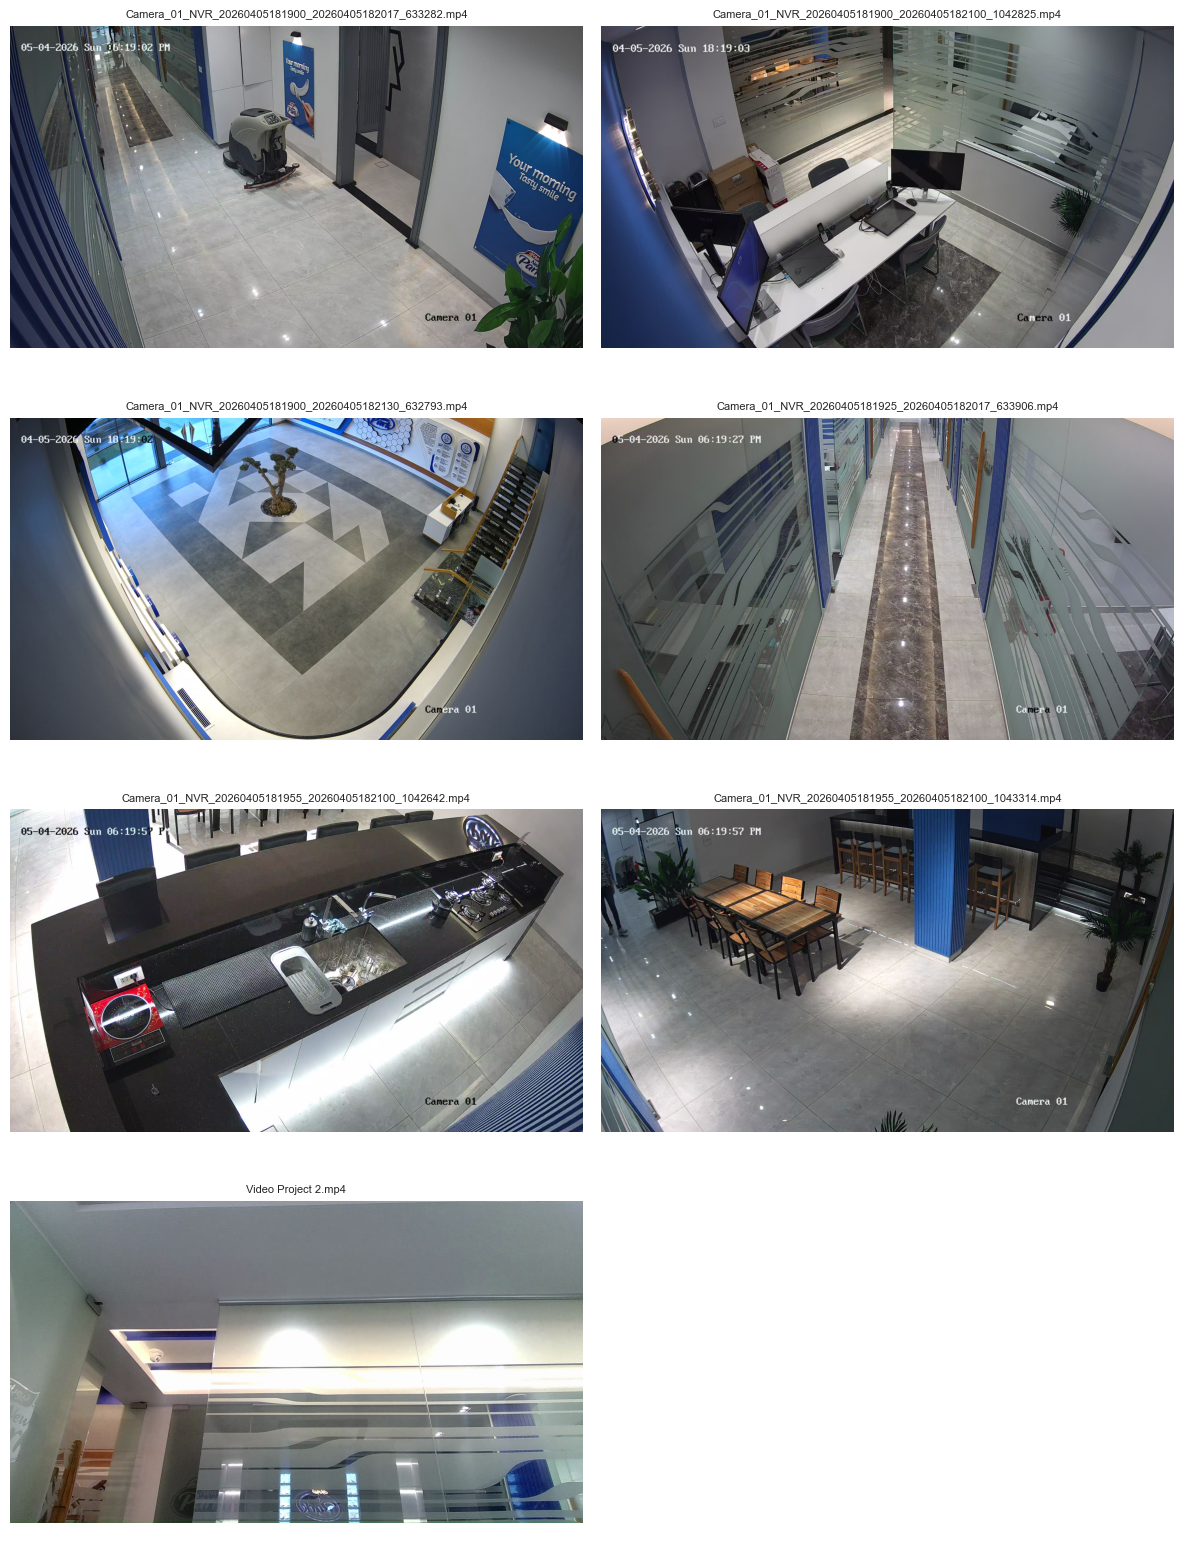

In [6]:
def grab_frame(path: Path, t_seconds: float = 1.0):
    cap = cv2.VideoCapture(str(path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(fps * t_seconds))
    ok, frame = cap.read()
    cap.release()
    return frame if ok else None

# Show one representative frame per clip
n = len(videos)
cols = 2
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 4*rows))
axes = np.atleast_2d(axes).ravel()
for ax, v in zip(axes, videos):
    f = grab_frame(v, t_seconds=3.0)
    if f is not None:
        ax.imshow(cv2.cvtColor(f, cv2.COLOR_BGR2RGB))
    ax.set_title(v.name, fontsize=8)
    ax.axis("off")
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()


## 3. Identity system — enrollment

The system identifies employees by comparing runtime embeddings against an **enrolled
gallery**. For each employee we collect:

* One or more frontal face photos → **face embedding** (512-D ArcFace).
* Several full-body crops from different angles/cameras → **ReID embedding bank**
  (512-D OSNet). We keep *multiple* vectors per person because appearance varies a lot.

Place reference images under:

```
graduation project/gallery/<employee_name>/face/*.jpg
graduation project/gallery/<employee_name>/body/*.jpg
```

Running the enrollment cell produces `gallery/gallery.npz` which the online pipeline
loads once at startup.


In [10]:
# =====================================================================
# 3.1 — Face embedder (InsightFace)
# =====================================================================
class FaceEmbedder:
    """Wraps InsightFace's buffalo_l bundle (detector + ArcFace recognizer)."""
    def __init__(self, device: str = DEVICE):
        from insightface.app import FaceAnalysis
        providers = ["CUDAExecutionProvider", "CPUExecutionProvider"] if device == "cuda" \
                    else ["CPUExecutionProvider"]
        self.app = FaceAnalysis(name="buffalo_l", providers=providers)
        self.app.prepare(ctx_id=0 if device == "cuda" else -1, det_size=(640, 640))

    def embed(self, bgr_image: np.ndarray) -> Optional[np.ndarray]:
        """Return the L2-normalized 512-D face embedding of the LARGEST face, or None."""
        faces = self.app.get(bgr_image)
        if not faces:
            return None
        f = max(faces, key=lambda x: (x.bbox[2]-x.bbox[0]) * (x.bbox[3]-x.bbox[1]))
        v = f.normed_embedding.astype(np.float32)
        return v

    def embed_many(self, bgr_image: np.ndarray):
        """Return list of (bbox, embedding) for every detected face."""
        return [(f.bbox.astype(int), f.normed_embedding.astype(np.float32))
                for f in self.app.get(bgr_image)]


In [11]:
# =====================================================================
# 3.2 — ReID embedder (TorchReID / OSNet)
# =====================================================================
class ReIDEmbedder:
    """OSNet x1_0 trained on MSMT17 — solid generalisation to new cameras."""
    def __init__(self, device: str = DEVICE):
        import torchreid
        self.device = device
        self.model = torchreid.models.build_model(
            name="osnet_x1_0", num_classes=1000, pretrained=True
        ).to(device).eval()
        import torchvision.transforms as T
        self.tf = T.Compose([
            T.ToPILImage(),
            T.Resize((256, 128)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406],
                        std =[0.229, 0.224, 0.225]),
        ])

    @torch.inference_mode()
    def embed(self, bgr_crop: np.ndarray) -> np.ndarray:
        rgb = cv2.cvtColor(bgr_crop, cv2.COLOR_BGR2RGB)
        x = self.tf(rgb).unsqueeze(0).to(self.device)
        v = self.model(x).squeeze(0).cpu().numpy()
        v = v / (np.linalg.norm(v) + 1e-9)
        return v.astype(np.float32)

    @torch.inference_mode()
    def embed_batch(self, bgr_crops: List[np.ndarray]) -> np.ndarray:
        if not bgr_crops: return np.zeros((0, 512), np.float32)
        xs = torch.stack([self.tf(cv2.cvtColor(c, cv2.COLOR_BGR2RGB)) for c in bgr_crops]).to(self.device)
        v = self.model(xs).cpu().numpy()
        v = v / (np.linalg.norm(v, axis=1, keepdims=True) + 1e-9)
        return v.astype(np.float32)


In [12]:
# =====================================================================
# 3.3 — Gallery builder
# =====================================================================
@dataclasses.dataclass
class EmployeeGallery:
    names:         List[str]
    face_vecs:     np.ndarray           # (N, 512)
    reid_banks:    Dict[str, np.ndarray]  # name -> (K_i, 512)

    def save(self, path: Path):
        np.savez(path,
                 names=np.array(self.names),
                 face=self.face_vecs,
                 reid_keys=np.array(list(self.reid_banks.keys())),
                 **{f"reid_{k}": v for k, v in self.reid_banks.items()})
        print("Saved gallery:", path, "| employees:", len(self.names))

    @staticmethod
    def load(path: Path) -> "EmployeeGallery":
        z = np.load(path, allow_pickle=True)
        names = z["names"].tolist()
        reid  = {k: z[f"reid_{k}"] for k in z["reid_keys"]}
        return EmployeeGallery(names=names, face_vecs=z["face"], reid_banks=reid)


def build_gallery(gallery_dir: Path, face_emb: FaceEmbedder, reid_emb: ReIDEmbedder) -> EmployeeGallery:
    names, face_vecs, reid_banks = [], [], {}

    # Keep only real employee folders; ignore helper dirs like `_harvest`.
    people = []
    ignored = []
    for p in sorted(gallery_dir.iterdir()):
        if not p.is_dir():
            continue
        if p.name.startswith("_") or p.name.startswith("."):
            ignored.append(p.name)
            continue
        if not ((p / "face").exists() or (p / "body").exists()):
            ignored.append(p.name)
            continue
        people.append(p)

    if ignored:
        print("Ignoring non-employee folders:", ", ".join(ignored))

    if not people:
        raise RuntimeError(
            f"No employee folders under {gallery_dir}. "
            "Expected layout: gallery/<employee_name>/{face,body}/..."
        )

    for person in people:
        face_dir, body_dir = person / "face", person / "body"
        # face
        face_imgs = sorted(list(face_dir.glob("*.*"))) if face_dir.exists() else []
        fvs = []
        for p in face_imgs:
            img = cv2.imread(str(p))
            if img is None: continue
            v = face_emb.embed(img)
            if v is not None: fvs.append(v)
        if not fvs:
            print(f"⚠ {person.name}: no usable face images — person will be ReID-only")
            face_vec = np.zeros(512, np.float32)
        else:
            face_vec = np.mean(np.stack(fvs), axis=0)
            face_vec /= (np.linalg.norm(face_vec) + 1e-9)
        # body
        body_imgs = sorted(list(body_dir.glob("*.*"))) if body_dir.exists() else []
        crops = [cv2.imread(str(p)) for p in body_imgs]
        crops = [c for c in crops if c is not None]
        bank  = reid_emb.embed_batch(crops) if crops else np.zeros((0, 512), np.float32)

        names.append(person.name)
        face_vecs.append(face_vec)
        reid_banks[person.name] = bank
        print(f"  + {person.name:20s}  faces:{len(fvs):2d}  body:{len(crops):2d}")
    return EmployeeGallery(names=names,
                           face_vecs=np.stack(face_vecs),
                           reid_banks=reid_banks)


In [13]:
# Example — build & save the gallery (run once after you populate /gallery)
face_emb = FaceEmbedder()
reid_emb = ReIDEmbedder()
gallery  = build_gallery(GALLERY_DIR, face_emb, reid_emb)
gallery.save(GALLERY_DIR / "gallery.npz")


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/omarkhairat/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/omarkhairat/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/omarkhairat/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/omarkhairat/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/omarkhairat/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None

## 4. Detection + tracking

Ultralytics ships YOLOv8 with ByteTrack wired in. We call `model.track(..., persist=True)`
and receive boxes **plus** a stable `track_id` per object. We keep only the classes we
care about (person / phone / laptop) and discard everything else.

ByteTrack's strength: it keeps tentative tracks even during low-confidence frames, so
short occlusions don't fragment identities. Its weakness: over long occlusions the
`track_id` will flip — that's exactly why we also run ReID-based identity fusion downstream.


In [14]:
import contextlib

@contextlib.contextmanager
def _allow_legacy_torch_load():
    """Temporarily force torch.load(weights_only=False).

    PyTorch >= 2.6 flipped the default of `weights_only` from False to True for
    security. The pretrained YOLOv8 weights file is a pickled `DetectionModel`
    object, which the new strict default refuses to unpickle, raising
    `WeightsUnpickler error: Unsupported global ...`.

    Ultralytics >= 8.3 calls `torch.load(..., weights_only=False)` itself; on
    older Ultralytics (e.g. 8.2.x) we have to opt out from the outside. This
    context manager restores the original `torch.load` immediately after the
    weights are loaded, so the relaxation does NOT leak into the rest of the
    process.
    """
    import torch
    orig = torch.load
    def _loader(*args, **kwargs):
        kwargs.setdefault("weights_only", False)
        return orig(*args, **kwargs)
    torch.load = _loader
    try:
        yield
    finally:
        torch.load = orig


class PersonObjectDetector:
    """Thin wrapper around Ultralytics YOLOv8 + ByteTrack."""
    def __init__(self, weights: str = YOLO_WEIGHTS, device: str = DEVICE):
        from ultralytics import YOLO
        with _allow_legacy_torch_load():
            self.model = YOLO(weights)
        self.device = device
        self.class_names = TARGET_CLASSES
        self.keep = set(TARGET_CLASSES.keys())

    def track(self, frame_bgr: np.ndarray):
        """Returns a list of dicts {bbox_xyxy, conf, cls_id, cls_name, track_id}."""
        res = self.model.track(frame_bgr,
                               persist=True,
                               conf=DET_CONF,
                               iou=DET_IOU,
                               tracker=TRACKER_CFG,
                               device=self.device,
                               verbose=False)[0]
        out = []
        if res.boxes is None or res.boxes.id is None:
            return out
        xyxy = res.boxes.xyxy.cpu().numpy().astype(int)
        conf = res.boxes.conf.cpu().numpy()
        cls  = res.boxes.cls.cpu().numpy().astype(int)
        ids  = res.boxes.id.cpu().numpy().astype(int)
        for b, c, k, tid in zip(xyxy, conf, cls, ids):
            if k not in self.keep: continue
            out.append(dict(bbox=b, conf=float(c), cls_id=int(k),
                            cls_name=self.class_names[int(k)], track_id=int(tid)))
        return out


## 5. Identity fusion — *which* employee is this track?

The tracker gives us *short-term* identity (`track_id`). We need *long-term* identity
(`employee_id`). The `IdentityFuser` does this by maintaining, for every active track,
a rolling tally of per-frame identity guesses.

A frame contributes a guess when it passes either of two tests:

1. **Face match**: a face was detected inside the person crop AND its cosine similarity
   with some gallery face vector exceeds `FACE_MATCH_THR`.
2. **ReID match**: the person crop's OSNet embedding has cosine similarity with *any*
   vector in some employee's ReID bank above `REID_MATCH_THR`.

Face votes are **weighted 2×** because face embeddings are much more discriminative than
ReID vectors. Once a track accumulates at least 5 votes with a clear winner, that
`employee_id` sticks — new votes just keep confirming it, and brief mismatches are
averaged out.

> **Implementation tip:** comparing against the gallery is a matrix multiply
> (`query @ gallery.T`) because all vectors are L2-normalised, so we just take the
> argmax. No per-pair loops.


In [15]:
def cosine_matrix(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Rows of a vs rows of b. Both must already be L2-normalised."""
    if a.size == 0 or b.size == 0:
        return np.zeros((a.shape[0] if a.ndim == 2 else 0,
                         b.shape[0] if b.ndim == 2 else 0), np.float32)
    return a @ b.T


class IdentityFuser:
    def __init__(self, gallery: EmployeeGallery,
                 face_emb: FaceEmbedder, reid_emb: ReIDEmbedder,
                 face_thr=FACE_MATCH_THR, reid_thr=REID_MATCH_THR,
                 window=FUSE_WINDOW):
        self.gallery   = gallery
        self.face_emb  = face_emb
        self.reid_emb  = reid_emb
        self.face_thr  = face_thr
        self.reid_thr  = reid_thr
        self.window    = window
        # track_id -> deque of (employee_name, weight)
        self.votes = collections.defaultdict(lambda: collections.deque(maxlen=window))
        # track_id -> committed name
        self.committed: Dict[int, str] = {}

    # ----- matchers -------------------------------------------------------
    def _match_face(self, crop_bgr: np.ndarray) -> Optional[Tuple[str, float]]:
        v = self.face_emb.embed(crop_bgr)
        if v is None: return None
        sims = cosine_matrix(v[None, :], self.gallery.face_vecs)[0]
        i = int(np.argmax(sims)); s = float(sims[i])
        if s >= self.face_thr:
            return self.gallery.names[i], s
        return None

    def _match_reid(self, crop_bgr: np.ndarray) -> Optional[Tuple[str, float]]:
        h, w = crop_bgr.shape[:2]
        # Tiny crops are mostly interpolation noise after resize(256x128).
        if h < REID_MIN_CROP_H or w < REID_MIN_CROP_W:
            return None

        v = self.reid_emb.embed(crop_bgr)
        scores = {}
        for name, bank in self.gallery.reid_banks.items():
            if bank.size == 0:
                continue
            sims = bank @ v
            k = min(REID_TOPK_BANK, sims.shape[0])
            topk = np.partition(sims, -k)[-k:]
            scores[name] = float(np.mean(topk))

        if not scores:
            return None

        ranked = sorted(scores.items(), key=lambda kv: kv[1], reverse=True)
        best_name, best_s = ranked[0]
        second_s = ranked[1][1] if len(ranked) > 1 else -1.0

        # Accept only if absolute score is high enough AND winner is separated.
        if best_s >= self.reid_thr and (best_s - second_s) >= REID_MARGIN_THR:
            return best_name, best_s
        return None

    # ----- public api -----------------------------------------------------
    def update(self, track_id: int, crop_bgr: np.ndarray) -> str:
        # already committed? keep confirming silently but don't relabel
        if track_id in self.committed:
            return self.committed[track_id]

        guess = self._match_face(crop_bgr)
        if guess is not None:
            self.votes[track_id].append((guess[0], 2.0))   # face votes double
        else:
            guess = self._match_reid(crop_bgr)
            if guess is not None:
                self.votes[track_id].append((guess[0], 1.0))
            # No vote when evidence is weak/ambiguous. This avoids drowning
            # good identities under many low-information UNKNOWN frames.

        # tally
        tally = collections.Counter()
        for name, w in self.votes[track_id]:
            tally[name] += w
        if not tally: return UNKNOWN_LABEL
        winner, score = tally.most_common(1)[0]
        total = sum(tally.values())
        # commit only when we have strong evidence
        if winner != UNKNOWN_LABEL and score / total > 0.55 and score >= 5:
            self.committed[track_id] = winner
        return winner


## 6. Activity event engine

Now that every person has a stable `employee_id` we can emit high-level events.
We implement three detectors, each of them a small state-machine:

* **Presence** — employee enters / stays in / exits a polygonal zone (a desk area).
* **PhoneUse** — a `cell phone` bbox overlaps the employee's bbox (IoU ≥ threshold) for
  at least `PHONE_MIN_SECS`.
* **Interaction** — two identified employees' centroids stay within `PROXIMITY_PX` for
  at least `INTERACTION_MIN_SECS`.

The `EventLogger` *opens* an event when the condition first becomes true and *closes* it
when the condition has been false for more than a short grace period — so brief blips
don't create hundreds of rows.


In [16]:
from shapely.geometry import Polygon, Point, box as shapely_box

# ---- zone utilities ------------------------------------------------------
@dataclasses.dataclass
class Zone:
    name: str
    polygon: Polygon       # image-pixel polygon

    @classmethod
    def rect(cls, name, x1, y1, x2, y2):
        return cls(name, shapely_box(x1, y1, x2, y2))

    def contains_bbox(self, bbox_xyxy) -> bool:
        x1, y1, x2, y2 = bbox_xyxy
        # use the *foot* point — more stable for people standing / sitting
        foot = Point((x1 + x2) / 2, y2 - 0.05 * (y2 - y1))
        return self.polygon.contains(foot)

# Example desk zones — adjust after watching a frame from your camera
DEFAULT_ZONES = [
    Zone.rect("desk_A",  50,  200,  500, 650),
    Zone.rect("desk_B", 550,  200, 1000, 650),
    Zone.rect("common", 1020, 200, 1900, 1050),
]


In [17]:
# ---- event bookkeeping ---------------------------------------------------
@dataclasses.dataclass
class Event:
    employee_id:  str
    event_type:   str           # presence / phone_use / interaction
    start_frame:  int
    end_frame:    Optional[int] = None
    start_ts:     Optional[float] = None
    end_ts:       Optional[float] = None
    details:      dict = dataclasses.field(default_factory=dict)

    @property
    def duration_s(self):
        if self.start_ts is None or self.end_ts is None: return None
        return round(self.end_ts - self.start_ts, 2)


class EventEngine:
    """State-machine over per-frame observations → list[Event]."""
    def __init__(self, fps: float, zones: List[Zone],
                 grace_s: float = 1.5):
        self.fps = fps
        self.zones = zones
        self.grace_frames = int(grace_s * fps)
        # open events keyed by a canonical string
        self.open: Dict[str, Event] = {}
        # frame idx when the condition was last true
        self.last_seen: Dict[str, int] = {}
        self.all: List[Event] = []

    def _key(self, kind, *parts):
        return kind + "::" + "::".join(str(p) for p in parts)

    def _start_or_refresh(self, key, kind, employee_id, frame_idx, details=None):
        if key not in self.open:
            self.open[key] = Event(employee_id=employee_id, event_type=kind,
                                   start_frame=frame_idx,
                                   start_ts=frame_idx / self.fps,
                                   details=details or {})
        self.last_seen[key] = frame_idx

    def _close_stale(self, frame_idx):
        for key in list(self.open.keys()):
            if frame_idx - self.last_seen[key] > self.grace_frames:
                ev = self.open.pop(key)
                ev.end_frame = self.last_seen[key]
                ev.end_ts    = ev.end_frame / self.fps
                self.all.append(ev)
                del self.last_seen[key]

    # --- per-frame update -------------------------------------------------
    def update(self, frame_idx: int,
               people: List[dict],
               phones: List[dict],
               laptops: List[dict],
               monitors: List[dict]):
        """
        people:   [{employee_id, bbox, ...}, ...]
        phones:   [{bbox}, ...]
        laptops:  [{bbox}, ...]
        monitors: [{bbox}, ...]
        """
        def _bbox_inter_metrics(a, b):
            ax1, ay1, ax2, ay2 = a
            bx1, by1, bx2, by2 = b
            ix1, iy1 = max(ax1, bx1), max(ay1, by1)
            ix2, iy2 = min(ax2, bx2), min(ay2, by2)
            if ix2 <= ix1 or iy2 <= iy1:
                return 0.0, 0.0
            inter = float((ix2 - ix1) * (iy2 - iy1))
            a_area = float(max(0, ax2 - ax1) * max(0, ay2 - ay1))
            b_area = float(max(0, bx2 - bx1) * max(0, by2 - by1))
            iou = inter / (a_area + b_area - inter + 1e-9)
            overlap_on_b = inter / (b_area + 1e-9)
            return iou, overlap_on_b

        # presence
        # If multiple zones contain the same person, pick ONE zone with priority:
        # 1) desk_* zones, 2) otherwise smallest containing zone.
        for p in people:
            containing = [z for z in self.zones if z.contains_bbox(p["bbox"])]
            if not containing:
                continue
            desk_containing = [z for z in containing if z.name.lower().startswith("desk")]
            chosen = (sorted(desk_containing, key=lambda z: z.polygon.area)[0]
                      if desk_containing
                      else sorted(containing, key=lambda z: z.polygon.area)[0])
            k = self._key("presence", p["employee_id"], chosen.name)
            self._start_or_refresh(k, "presence", p["employee_id"],
                                   frame_idx, details={"zone": chosen.name})

        # phone use
        for p in people:
            pb = p["bbox"]
            for ph in phones:
                iou, overlap_on_phone = _bbox_inter_metrics(pb, ph["bbox"])
                if iou >= PHONE_IOU_THR or overlap_on_phone > 0.5:
                    k = self._key("phone_use", p["employee_id"])
                    self._start_or_refresh(k, "phone_use", p["employee_id"], frame_idx)

        # office-only working: employee in desk zone with laptop+monitor nearby.
        # "screen on" is a detector proxy (we cannot directly infer pixel-level
        # monitor power state from this model stack).
        desk_zones = [z for z in self.zones if z.name.lower().startswith("desk")]
        for p in people:
            if p["employee_id"] == UNKNOWN_LABEL:
                continue
            pb = p["bbox"]
            for z in desk_zones:
                if not z.contains_bbox(pb):
                    continue

                has_laptop = any(
                    _bbox_inter_metrics(pb, d["bbox"])[0] >= WORK_DEVICE_IOU_THR or
                    _bbox_inter_metrics(pb, d["bbox"])[1] >= WORK_DEVICE_OVERLAP_ON_DEVICE_THR
                    for d in laptops
                )
                has_monitor = any(
                    _bbox_inter_metrics(pb, d["bbox"])[0] >= WORK_DEVICE_IOU_THR or
                    _bbox_inter_metrics(pb, d["bbox"])[1] >= WORK_DEVICE_OVERLAP_ON_DEVICE_THR
                    for d in monitors
                )

                if has_laptop and has_monitor:
                    k = self._key("working", p["employee_id"], z.name)
                    self._start_or_refresh(
                        k, "working", p["employee_id"], frame_idx,
                        details={"zone": z.name, "work_proxy": "laptop+monitor"}
                    )

        # interactions (pairwise proximity)
        ids = [p for p in people if p["employee_id"] != UNKNOWN_LABEL]
        for i in range(len(ids)):
            for j in range(i+1, len(ids)):
                a, b = ids[i], ids[j]
                if a["employee_id"] == b["employee_id"]:
                    continue
                ca = ((a["bbox"][0] + a["bbox"][2]) / 2, (a["bbox"][1] + a["bbox"][3]) / 2)
                cb = ((b["bbox"][0] + b["bbox"][2]) / 2, (b["bbox"][1] + b["bbox"][3]) / 2)
                dist = math.hypot(ca[0] - cb[0], ca[1] - cb[1])
                if dist <= PROXIMITY_PX:
                    pair = tuple(sorted([a["employee_id"], b["employee_id"]]))
                    k = self._key("interaction", *pair)
                    self._start_or_refresh(k, "interaction", f"{pair[0]} <-> {pair[1]}",
                                           frame_idx, details={"peers": pair, "dist": round(dist, 1)})

        self._close_stale(frame_idx)

    def flush(self, frame_idx: int):
        """Force-close remaining open events — call at end of video."""
        for key, ev in list(self.open.items()):
            ev.end_frame = self.last_seen.get(key, frame_idx)
            ev.end_ts    = ev.end_frame / self.fps
            self.all.append(ev)
        self.open.clear(); self.last_seen.clear()

    def to_dataframe(self, min_secs_by_type: Optional[dict] = None) -> pd.DataFrame:
        mins = min_secs_by_type or {
            "presence":    PRESENCE_MIN_SECS,
            "phone_use":   PHONE_MIN_SECS,
            "working":     WORKING_MIN_SECS,
            "interaction": INTERACTION_MIN_SECS,
        }
        rows = []
        for ev in self.all:
            if ev.duration_s is None: continue
            if ev.duration_s < mins.get(ev.event_type, 0): continue
            rows.append({
                "employee_id":  ev.employee_id,
                "event_type":   ev.event_type,
                "start_s":      round(ev.start_ts, 2),
                "end_s":        round(ev.end_ts, 2),
                "duration_s":   ev.duration_s,
                **ev.details,
            })

        # Keep a stable schema for empty scenes so downstream batch code can
        # concatenate/sort safely without KeyError on missing columns.
        if not rows:
            return pd.DataFrame(columns=["employee_id", "event_type", "start_s", "end_s", "duration_s"])

        return pd.DataFrame(rows).sort_values(["start_s","employee_id"]).reset_index(drop=True)


## 7. End-to-end pipeline

Everything above plugs into a single orchestrator. `EmployeeActivityMonitor.run(video)`
iterates frames, runs detection + tracking, updates identity fusion, feeds the event
engine, and writes an annotated output video.


In [21]:
COLORS = np.random.randint(0, 255, size=(128, 3), dtype=np.uint8)

def color_for(name: str):
    h = sum(ord(c) for c in name) % 128
    return tuple(int(v) for v in COLORS[h])

def draw_overlay(frame, boxes_people, boxes_phones, boxes_laptops, boxes_monitors,
                 zones, frame_idx, fps, events_just_opened):
    vis = frame.copy()
    # zones
    for z in zones:
        pts = np.array(z.polygon.exterior.coords, np.int32)
        cv2.polylines(vis, [pts], True, (200, 200, 200), 1, cv2.LINE_AA)
        cv2.putText(vis, z.name, tuple(pts[0]), cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (200, 200, 200), 1, cv2.LINE_AA)

    # phones
    for ph in boxes_phones:
        x1, y1, x2, y2 = ph["bbox"]
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 180, 255), 2)
        cv2.putText(vis, "phone", (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX,
                    0.4, (0, 180, 255), 1, cv2.LINE_AA)

    # laptops
    for lp in boxes_laptops:
        x1, y1, x2, y2 = lp["bbox"]
        cv2.rectangle(vis, (x1, y1), (x2, y2), (80, 210, 80), 2)
        cv2.putText(vis, "laptop", (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX,
                    0.4, (80, 210, 80), 1, cv2.LINE_AA)

    # monitors (COCO tv class used as monitor/screen proxy)
    for mo in boxes_monitors:
        x1, y1, x2, y2 = mo["bbox"]
        cv2.rectangle(vis, (x1, y1), (x2, y2), (220, 120, 30), 2)
        cv2.putText(vis, "monitor", (x1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX,
                    0.4, (220, 120, 30), 1, cv2.LINE_AA)

    # people
    for p in boxes_people:
        x1, y1, x2, y2 = p["bbox"]
        name = p["employee_id"]
        col = color_for(name)
        cv2.rectangle(vis, (x1, y1), (x2, y2), col, 2)
        cv2.putText(vis, f"{name} #{p['track_id']}", (x1, max(y1 - 6, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, col, 2, cv2.LINE_AA)

    # HUD
    t = frame_idx / max(fps, 1e-6)
    cv2.putText(vis, f"t={t:6.2f}s  frame={frame_idx}", (10, 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)

    # ticker of new events
    for i, ev in enumerate(events_just_opened[-3:]):
        cv2.putText(vis, f"• {ev}", (10, 55 + 20 * i),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 180), 1, cv2.LINE_AA)
    return vis


In [22]:
class EmployeeActivityMonitor:
    def __init__(self, gallery_path: Optional[Path] = None,
                 zones: List[Zone] = None):
        self.face_emb = FaceEmbedder()
        self.reid_emb = ReIDEmbedder()
        self.detector = PersonObjectDetector()
        self.gallery  = None
        self.fuser    = None
        if gallery_path and Path(gallery_path).exists():
            self.gallery = EmployeeGallery.load(Path(gallery_path))
            self.fuser   = IdentityFuser(self.gallery, self.face_emb, self.reid_emb)
        self.zones = zones or DEFAULT_ZONES

    # -------------------------------------------------------------------
    def run(self, video_path: Path, out_path: Optional[Path] = None,
            max_frames: Optional[int] = None,
            frame_stride: int = FRAME_STRIDE,
            zones: Optional[List[Zone]] = None,
            reset_identity_state: bool = True) -> pd.DataFrame:

        # Track IDs restart from small integers on every new video stream.
        # Reset fuser state between clips to avoid cross-video track_id collisions.
        if reset_identity_state and self.fuser is not None:
            self.fuser.votes.clear()
            self.fuser.committed.clear()

        active_zones = zones or self.zones

        cap = cv2.VideoCapture(str(video_path))
        fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
        W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        N = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        writer = None
        if out_path is not None:
            fourcc = cv2.VideoWriter_fourcc(*"mp4v")
            writer = cv2.VideoWriter(str(out_path), fourcc, DRAW_FPS, (W, H))

        engine = EventEngine(fps=fps/frame_stride, zones=active_zones)
        recent_opens = []

        pbar = tqdm(total=min(N, max_frames or N), desc=video_path.name)
        idx = 0
        processed = 0
        while True:
            ok, frame = cap.read()
            if not ok: break
            if idx % frame_stride != 0:
                idx += 1; continue
            if max_frames is not None and processed >= max_frames: break

            dets = self.detector.track(frame)
            people, phones, laptops, monitors = [], [], [], []
            for d in dets:
                if d["cls_name"] == "person":
                    x1,y1,x2,y2 = d["bbox"]
                    x1,y1 = max(0,x1), max(0,y1)
                    x2,y2 = min(W,x2), min(H,y2)
                    crop = frame[y1:y2, x1:x2]
                    name = UNKNOWN_LABEL
                    if self.fuser is not None and crop.size > 0:
                        name = self.fuser.update(d["track_id"], crop)
                    people.append({**d, "employee_id": name})
                elif d["cls_name"] == "cell phone":
                    phones.append(d)
                elif d["cls_name"] == "laptop":
                    laptops.append(d)
                elif d["cls_name"] == "monitor":
                    monitors.append(d)

            prev_count = len(engine.all)
            engine.update(processed, people, phones, laptops, monitors)
            new_events = engine.all[prev_count:]
            for ev in new_events:
                recent_opens.append(f"{ev.event_type}: {ev.employee_id} @ {ev.start_ts:.1f}s")

            if writer is not None:
                vis = draw_overlay(
                    frame,
                    people,
                    phones,
                    laptops,
                    monitors,
                    active_zones,
                    processed,
                    fps/frame_stride,
                    recent_opens,
                )
                writer.write(vis)

            idx += 1; processed += 1; pbar.update(1)
        pbar.close(); cap.release()
        if writer is not None: writer.release()
        engine.flush(processed)
        return engine.to_dataframe()


In [23]:
# -- demo run (uncomment once gallery is built) ----------------------------
# monitor = EmployeeActivityMonitor(gallery_path=GALLERY_DIR / "gallery.npz",
#                                   zones=DEFAULT_ZONES)
# video   = sorted(DATA_DIR.glob("*.mp4"))[0]
# events  = monitor.run(video,
#                       out_path=OUT_DIR / (video.stem + "_annotated.mp4"),
#                       max_frames=600,            # for a smoke test
#                       frame_stride=2)
# events.to_csv(OUT_DIR / (video.stem + "_events.csv"), index=False)
# events.head(20)


## 7.4 — Multi-scene video flow (all CCTV clips)

Use this section to run the activity pipeline across all known scenes and export
one combined event table.

Defined scenes:

- `Camera_01_NVR_20260405181900_20260405182017_633282.mp4` → `hall`
- `Camera_01_NVR_20260405181900_20260405182100_1042825.mp4` → `office_area`
- `Camera_01_NVR_20260405181900_20260405182130_632793.mp4` → `main_entrance_exit`
- `Camera_01_NVR_20260405181925_20260405182017_633906.mp4` → `offices_hall`
- `Camera_01_NVR_20260405181955_20260405182100_1042642.mp4` → `kitchen_area`
- `Camera_01_NVR_20260405181955_20260405182100_1043314.mp4` → `cafeteria`
- `Video Project 2.mp4` → `check_in_face_id`

Notes:

1. Identity state is reset per clip (to prevent track-id collisions across videos).
2. All clip-level outputs are saved under `outputs/multi_scene/`.
3. The combined event file is saved as `outputs/multi_scene/all_scenes_events.csv`.


In [24]:
# ---------------------------------------------------------------------------
# Multi-scene orchestration
# ---------------------------------------------------------------------------
SCENE_VIDEO_FLOW = [
    {"file": "Camera_01_NVR_20260405181900_20260405182017_633282.mp4", "scene": "hall", "kind": "surveillance"},
    {"file": "Camera_01_NVR_20260405181900_20260405182100_1042825.mp4", "scene": "office_area", "kind": "surveillance"},
    {"file": "Camera_01_NVR_20260405181900_20260405182130_632793.mp4", "scene": "main_entrance_exit", "kind": "surveillance"},
    {"file": "Camera_01_NVR_20260405181925_20260405182017_633906.mp4", "scene": "offices_hall", "kind": "surveillance"},
    {"file": "Camera_01_NVR_20260405181955_20260405182100_1042642.mp4", "scene": "kitchen_area", "kind": "surveillance"},
    {"file": "Camera_01_NVR_20260405181955_20260405182100_1043314.mp4", "scene": "cafeteria", "kind": "surveillance"},
    {"file": "Video Project 2.mp4", "scene": "check_in_face_id", "kind": "check_in"},
]

# ---------------------------------------------------------------------------
# Per-scene zone calibration
# ---------------------------------------------------------------------------
# DEFAULT_ZONES were authored on a 1920x1080 canvas. Most of your clips are
# 3200x1800 or 3840x2160, so we scale defaults per scene and allow manual
# overrides as pixel rectangles.
BASE_ZONE_CANVAS_WH = (1920, 1080)

# Manual per-scene rectangles in source pixel space:
#   scene -> [(zone_name, x1, y1, x2, y2), ...]
# Policy reminder:
#   - Define desk_* zones for office_area (working event depends on them).
#   - Non-office scenes default to one whole-scene area zone unless overridden.
#
# Recommended: define office desks once here and keep everything centralized.
OFFICE_DESK_ZONE_RECTS: List[Tuple[str, int, int, int, int]] = [
    # ("desk_hasan", x1, y1, x2, y2),
    # ("desk_majd",  x1, y1, x2, y2),
    # ("desk_other", x1, y1, x2, y2),
    # Optional fallback area in office (non-desk):
    # ("office_common", x1, y1, x2, y2),
]

SCENE_ZONE_RECTS: Dict[str, List[Tuple[str, int, int, int, int]]] = {
    "office_area": OFFICE_DESK_ZONE_RECTS,
}


def _video_wh(path: Path) -> Tuple[int, int]:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        return BASE_ZONE_CANVAS_WH
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)) or BASE_ZONE_CANVAS_WH[0]
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)) or BASE_ZONE_CANVAS_WH[1]
    cap.release()
    return (w, h)


def _scale_default_zones_for_video(path: Path) -> List[Zone]:
    w, h = _video_wh(path)
    bw, bh = BASE_ZONE_CANVAS_WH
    sx, sy = w / bw, h / bh
    zones = []
    for z in DEFAULT_ZONES:
        x1, y1, x2, y2 = z.polygon.bounds
        zones.append(Zone.rect(z.name,
                               int(round(x1 * sx)), int(round(y1 * sy)),
                               int(round(x2 * sx)), int(round(y2 * sy))))
    return zones


def _zones_from_rects(rects: List[Tuple[str, int, int, int, int]]) -> List[Zone]:
    return [Zone.rect(name, x1, y1, x2, y2) for name, x1, y1, x2, y2 in rects]


def _full_scene_zone(path: Path, scene_name: str) -> List[Zone]:
    w, h = _video_wh(path)
    return [Zone.rect(scene_name, 0, 0, max(1, w - 1), max(1, h - 1))]


def build_scene_zones(scene_rows,
                      manual_rects: Dict[str, List[Tuple[str, int, int, int, int]]]):
    """Policy:
    - office_area: desk-level zones (manual if provided, else scaled defaults)
    - non-office scenes: one scene-wide area zone by default
    """
    zones_by_scene: Dict[str, List[Zone]] = {}
    print("\nZone setup per scene:")
    for row in scene_rows:
        scene = row["scene"]
        path = row["path"]
        rects = manual_rects.get(scene, [])

        if rects:
            zones = _zones_from_rects(rects)
            source = "manual"
        elif scene == "office_area":
            zones = _scale_default_zones_for_video(path)
            source = "scaled_default_office"
        else:
            zones = _full_scene_zone(path, scene)
            source = "scene_wide"

        zones_by_scene[scene] = zones
        print(f"  - {scene:20s} ({path.name}): {source}, {len(zones)} zone(s)")
    return zones_by_scene


def preview_scene_zones(scene_row, zones: List[Zone], frame_at_sec: float = 0.0):
    """Quick visual sanity check for one scene's zone placement."""
    path = scene_row["path"]
    cap = cv2.VideoCapture(str(path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    target_frame = int(max(0.0, frame_at_sec) * fps)
    cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        print(f"Could not read frame from {path}")
        return

    vis = frame.copy()
    for z in zones:
        pts = np.array(z.polygon.exterior.coords, np.int32)
        cv2.polylines(vis, [pts], True, (255, 220, 0), 2, cv2.LINE_AA)
        cv2.putText(vis, z.name, tuple(pts[0]), cv2.FONT_HERSHEY_SIMPLEX,
                    0.7, (255, 220, 0), 2, cv2.LINE_AA)
    plt.figure(figsize=(12, 7))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.title(f"Zone preview — {scene_row['scene']} @ t={frame_at_sec:.1f}s")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def draw_scene_zone_rects(scene_row,
                          zone_names: List[str],
                          frame_at_sec: float = 0.0) -> List[Tuple[str, int, int, int, int]]:
    """Interactive helper: click 2 corners per zone on a frame.

    How to use:
      rects = draw_scene_zone_rects(scene_inputs[0], ["desk_A", "desk_B", "common"], frame_at_sec=10)
      SCENE_ZONE_RECTS[scene_inputs[0]["scene"]] = rects

    Notes:
      - For each zone, click top-left then bottom-right.
      - Close the figure after finishing each zone.
      - Works best in a notebook backend with interactive clicks enabled.
    """
    path = scene_row["path"]
    cap = cv2.VideoCapture(str(path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    target_frame = int(max(0.0, frame_at_sec) * fps)
    cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f"Could not read frame from {path}")

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    out = []

    for name in zone_names:
        fig, ax = plt.subplots(figsize=(12, 7))
        ax.imshow(rgb)
        ax.set_title(f"{scene_row['scene']} — draw '{name}' (click TL then BR)")
        ax.axis("off")
        plt.tight_layout()

        pts = plt.ginput(2, timeout=-1)
        plt.close(fig)

        if len(pts) < 2:
            print(f"Skipped '{name}' (not enough clicks).")
            continue

        (x1, y1), (x2, y2) = pts
        xa, xb = sorted([int(round(x1)), int(round(x2))])
        ya, yb = sorted([int(round(y1)), int(round(y2))])
        out.append((name, xa, ya, xb, yb))
        print(f"{name}: ({xa}, {ya}, {xb}, {yb})")

    return out


def calibrate_scene_zones(scene_inputs,
                          scene_name: str,
                          zone_names: List[str],
                          frame_at_sec: float = 0.0):
    """Run interactive zone drawing and update SCENE_ZONE_RECTS in-place."""
    matches = [r for r in scene_inputs if r["scene"] == scene_name]
    if not matches:
        raise ValueError(f"Scene '{scene_name}' not found in scene_inputs")
    rects = draw_scene_zone_rects(matches[0], zone_names, frame_at_sec=frame_at_sec)
    SCENE_ZONE_RECTS[scene_name] = rects
    print(f"\nUpdated SCENE_ZONE_RECTS['{scene_name}'] =")
    print(rects)


# Runtime controls for the batch run.
MULTI_FRAME_STRIDE = 2
MULTI_MAX_FRAMES   = None    # set e.g. 1200 for a faster smoke run
WRITE_ANNOTATED    = True


def _resolve_scene_inputs(flow_rows, data_dir: Path):
    rows = []
    missing = []
    for r in flow_rows:
        p = data_dir / r["file"]
        if not p.exists():
            missing.append(r["file"])
            continue
        rows.append({**r, "path": p})
    if missing:
        print("Missing files (skipped):")
        for m in missing:
            print("  -", m)
    return rows


def run_all_scenes(monitor: EmployeeActivityMonitor,
                   scene_rows,
                   zones_by_scene: Dict[str, List[Zone]],
                   out_dir: Path,
                   frame_stride: int = 2,
                   max_frames: Optional[int] = None,
                   write_annotated: bool = True) -> pd.DataFrame:
    out_dir.mkdir(parents=True, exist_ok=True)
    all_events = []

    for row in scene_rows:
        video_path = row["path"]
        scene_name = row["scene"]
        scene_kind = row["kind"]

        print(f"\n=== Running scene: {scene_name} ({video_path.name}) ===")

        annotated_path = None
        if write_annotated:
            annotated_path = out_dir / f"{video_path.stem}_annotated.mp4"

        zones = zones_by_scene.get(scene_name, DEFAULT_ZONES)

        ev = monitor.run(
            video_path=video_path,
            out_path=annotated_path,
            max_frames=max_frames,
            frame_stride=frame_stride,
            zones=zones,
            reset_identity_state=True,
        )

        if ev.empty:
            ev = pd.DataFrame(columns=["employee_id", "event_type", "start_s", "end_s", "duration_s"])

        ev["video_file"] = video_path.name
        ev["scene"] = scene_name
        ev["scene_kind"] = scene_kind

        clip_csv = out_dir / f"{video_path.stem}_events.csv"
        ev.to_csv(clip_csv, index=False)
        print(f"Saved: {clip_csv}")

        all_events.append(ev)

    if not all_events:
        return pd.DataFrame()

    combined = pd.concat(all_events, ignore_index=True)
    combined = combined.sort_values(["scene", "start_s", "employee_id"], kind="stable").reset_index(drop=True)
    return combined


scene_inputs = _resolve_scene_inputs(SCENE_VIDEO_FLOW, DATA_DIR)
multi_out_dir = OUT_DIR / "multi_scene"

scene_zones = build_scene_zones(scene_inputs, SCENE_ZONE_RECTS)
# Optional quick preview for one scene before full batch run:
# preview_scene_zones(scene_inputs[0], scene_zones[scene_inputs[0]["scene"]], frame_at_sec=10.0)

# Optional interactive calibration (run once per scene, then keep the rects):
# office_rects = draw_scene_zone_rects(
#     [r for r in scene_inputs if r["scene"] == "office_area"][0],
#     ["desk_hasan", "desk_majd", "desk_other", "office_common"],
#     frame_at_sec=10.0,
# )
# OFFICE_DESK_ZONE_RECTS[:] = office_rects
# scene_zones = build_scene_zones(scene_inputs, SCENE_ZONE_RECTS)

# Reuse one monitor instance for model warm-cache speed.
# run(..., reset_identity_state=True) ensures no cross-clip track-id leakage.
monitor_multi = EmployeeActivityMonitor(gallery_path=GALLERY_DIR / "gallery.npz", zones=DEFAULT_ZONES)

all_scene_events = run_all_scenes(
    monitor=monitor_multi,
    scene_rows=scene_inputs,
    zones_by_scene=scene_zones,
    out_dir=multi_out_dir,
    frame_stride=MULTI_FRAME_STRIDE,
    max_frames=MULTI_MAX_FRAMES,
    write_annotated=WRITE_ANNOTATED,
)

all_csv = multi_out_dir / "all_scenes_events.csv"
all_scene_events.to_csv(all_csv, index=False)
print(f"\nCombined events saved: {all_csv}")

if all_scene_events.empty:
    print("No events detected across scenes.")
else:
    display(all_scene_events.head(30))
    print("\nEvent count by scene / employee / type:")
    agg = (all_scene_events
           .groupby(["scene", "employee_id", "event_type"], as_index=False)["duration_s"]
           .sum()
           .sort_values(["scene", "employee_id", "duration_s"], ascending=[True, True, False]))
    display(agg)



Zone setup per scene:
  - hall                 (Camera_01_NVR_20260405181900_20260405182017_633282.mp4): scene_wide, 1 zone(s)
  - office_area          (Camera_01_NVR_20260405181900_20260405182100_1042825.mp4): scaled_default_office, 3 zone(s)
  - main_entrance_exit   (Camera_01_NVR_20260405181900_20260405182130_632793.mp4): scene_wide, 1 zone(s)
  - offices_hall         (Camera_01_NVR_20260405181925_20260405182017_633906.mp4): scene_wide, 1 zone(s)
  - kitchen_area         (Camera_01_NVR_20260405181955_20260405182100_1042642.mp4): scene_wide, 1 zone(s)
  - cafeteria            (Camera_01_NVR_20260405181955_20260405182100_1043314.mp4): scene_wide, 1 zone(s)
  - check_in_face_id     (Video Project 2.mp4): scene_wide, 1 zone(s)
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/omarkhairat/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options

Camera_01_NVR_20260405181900_20260405182017_633282.mp4:  50%|████▉     | 775/1551 [02:00<02:00,  6.45it/s]


Saved: /Users/omarkhairat/University/graduation project/outputs/multi_scene/Camera_01_NVR_20260405181900_20260405182017_633282_events.csv

=== Running scene: office_area (Camera_01_NVR_20260405181900_20260405182100_1042825.mp4) ===


Camera_01_NVR_20260405181900_20260405182100_1042825.mp4:  13%|█▎        | 320/2400 [00:53<05:56,  5.83it/s]

KeyboardInterrupt: 

### Interactive zone drawer (click to define rectangles)

Run the next cell to draw zones directly on a selected scene frame.

How to use:

1. Set `DRAW_SCENE` and `DRAW_ZONE_NAMES`.
2. Run the cell.
3. For each zone name, click **top-left** then **bottom-right**.
4. Close each figure after the two clicks.
5. The cell updates `SCENE_ZONE_RECTS` (and `OFFICE_DESK_ZONE_RECTS` when scene is `office_area`) and prints copy/paste-ready coordinates.


[hevc @ 0x3878bf5b0] Could not find ref with POC 33


KeyboardInterrupt: 

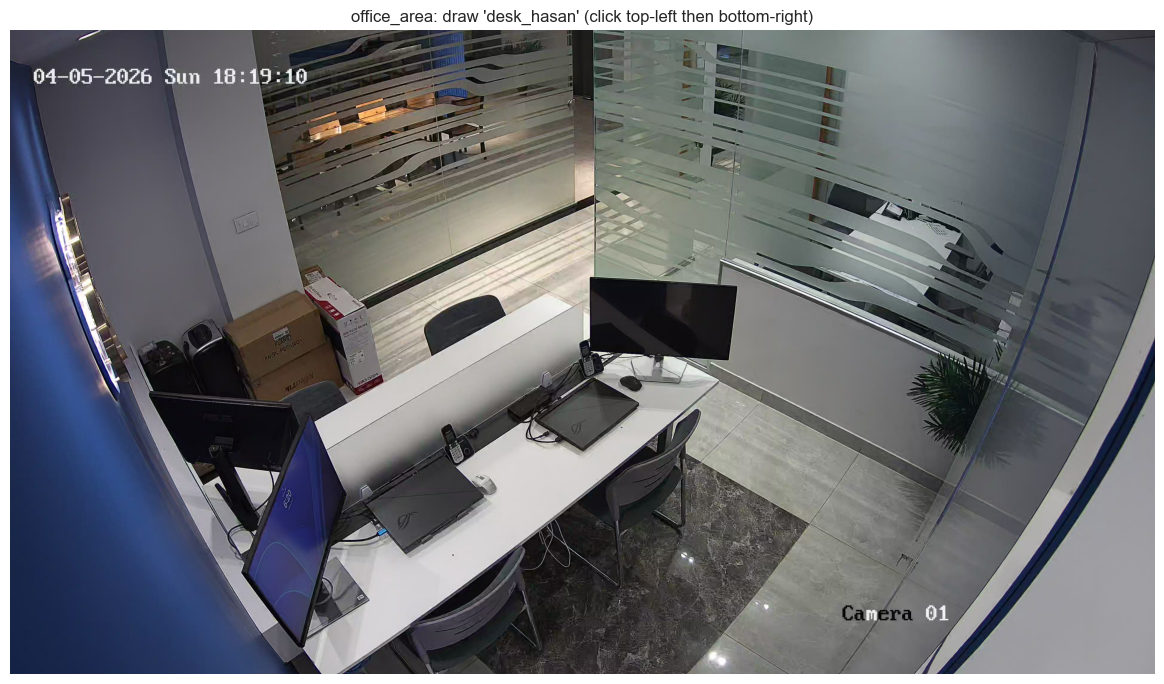

In [25]:
# =========================================================================
# Interactive zone drawer (standalone helper)
# =========================================================================
# Edit these for each scene you want to calibrate.
DRAW_SCENE = "office_area"
DRAW_ZONE_NAMES = ["desk_hasan", "desk_majd", "desk_other", "office_common"]
DRAW_FRAME_AT_SEC = 10.0


def _get_scene_rows_for_drawer():
    if "scene_inputs" in globals() and scene_inputs:
        return scene_inputs
    # fallback if orchestration cell has not been run yet
    return _resolve_scene_inputs(SCENE_VIDEO_FLOW, DATA_DIR)


def draw_zones_interactive(scene_name: str,
                           zone_names: List[str],
                           frame_at_sec: float = 0.0):
    rows = _get_scene_rows_for_drawer()
    match = [r for r in rows if r["scene"] == scene_name]
    if not match:
        raise ValueError(f"Scene '{scene_name}' not found. Available: {[r['scene'] for r in rows]}")

    row = match[0]
    path = row["path"]
    cap = cv2.VideoCapture(str(path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    target_frame = int(max(0.0, frame_at_sec) * fps)
    cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f"Could not read frame from {path}")

    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    rects: List[Tuple[str, int, int, int, int]] = []

    for name in zone_names:
        vis = rgb.copy()

        # Draw already accepted rectangles for context.
        for zn, x1, y1, x2, y2 in rects:
            cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 220, 0), 2)
            cv2.putText(vis, zn, (x1, max(18, y1 - 6)), cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (255, 220, 0), 2, cv2.LINE_AA)

        fig, ax = plt.subplots(figsize=(13, 7))
        ax.imshow(vis)
        ax.set_title(f"{scene_name}: draw '{name}' (click top-left then bottom-right)")
        ax.axis("off")
        plt.tight_layout()

        pts = plt.ginput(2, timeout=-1)
        plt.close(fig)

        if len(pts) < 2:
            print(f"Skipped '{name}' (not enough clicks).")
            continue

        (x1, y1), (x2, y2) = pts
        xa, xb = sorted([int(round(x1)), int(round(x2))])
        ya, yb = sorted([int(round(y1)), int(round(y2))])
        rects.append((name, xa, ya, xb, yb))
        print(f"{name}: ({xa}, {ya}, {xb}, {yb})")

    # Persist to scene config
    SCENE_ZONE_RECTS[scene_name] = rects
    if scene_name == "office_area":
        OFFICE_DESK_ZONE_RECTS[:] = rects

    print("\nUpdated SCENE_ZONE_RECTS entry:")
    print(f"SCENE_ZONE_RECTS['{scene_name}'] = {rects}")

    if scene_name == "office_area":
        print("\nUpdated OFFICE_DESK_ZONE_RECTS:")
        print(f"OFFICE_DESK_ZONE_RECTS = {rects}")

    # Optional immediate preview
    new_zones = _zones_from_rects(rects)
    preview_scene_zones(row, new_zones, frame_at_sec=frame_at_sec)

    return rects


# Run drawer
drawn_rects = draw_zones_interactive(
    scene_name=DRAW_SCENE,
    zone_names=DRAW_ZONE_NAMES,
    frame_at_sec=DRAW_FRAME_AT_SEC,
)


### Interactive multi-scene zone calibration (sequential)

This helper walks through multiple scenes one by one and opens the interactive
rectangle drawer for each scene.

Outputs:

- updates `SCENE_ZONE_RECTS` in-memory
- updates `OFFICE_DESK_ZONE_RECTS` when calibrating `office_area`
- prints a final copy/paste-ready dictionary block for all calibrated scenes

Usage:

1. Set `SEQUENTIAL_ZONE_PLAN` (scene names, zone labels, and frame time).
2. Run the cell.
3. For each prompted zone: click top-left then bottom-right.
4. Rebuild scene zones and re-run multi-scene orchestration.


In [8]:
# =========================================================================
# Interactive sequential zone calibration across multiple scenes
# =========================================================================
SEQUENTIAL_ZONE_PLAN = [
    {"scene": "office_area", "zones": ["desk_hasan", "desk_majd", "desk_other", "office_common"], "t_sec": 10.0},
    {"scene": "hall", "zones": ["hall"], "t_sec": 8.0},
    {"scene": "main_entrance_exit", "zones": ["main_entrance_exit"], "t_sec": 8.0},
    {"scene": "offices_hall", "zones": ["offices_hall"], "t_sec": 8.0},
    {"scene": "kitchen_area", "zones": ["kitchen_area"], "t_sec": 8.0},
    {"scene": "cafeteria", "zones": ["cafeteria"], "t_sec": 8.0},
    {"scene": "check_in_face_id", "zones": ["check_in_face_id"], "t_sec": 8.0},
]

RUN_ONLY_SCENES = None  # e.g. ["office_area", "hall"] to calibrate subset


def _norm_zone_rects_for_print(rects):
    return [
        (name, int(x1), int(y1), int(x2), int(y2))
        for name, x1, y1, x2, y2 in rects
    ]


def calibrate_scenes_sequential(plan, run_only_scenes=None):
    available_rows = _get_scene_rows_for_drawer()
    available_names = {r["scene"] for r in available_rows}

    selected = []
    for step in plan:
        scene = step["scene"]
        if scene not in available_names:
            print(f"Skipping unknown scene '{scene}' (not found in scene_inputs).")
            continue
        if run_only_scenes is not None and scene not in set(run_only_scenes):
            continue
        selected.append(step)

    if not selected:
        print("No scenes selected for calibration.")
        return {}

    print("Scenes to calibrate:")
    for s in selected:
        print(f"  - {s['scene']} @ t={s['t_sec']}s, zones={s['zones']}")

    calibrated = {}
    for step in selected:
        scene = step["scene"]
        zones = step["zones"]
        t_sec = float(step.get("t_sec", 0.0))

        print("\n" + "=" * 78)
        print(f"Calibrating scene: {scene}")
        print("=" * 78)

        rects = draw_zones_interactive(scene_name=scene,
                                       zone_names=zones,
                                       frame_at_sec=t_sec)
        calibrated[scene] = rects

    # Print a copy-paste ready block
    print("\n\n===== COPY/PASTE THIS INTO SCENE_ZONE_RECTS =====")
    print("SCENE_ZONE_RECTS = {")
    for scene, rects in calibrated.items():
        rects_norm = _norm_zone_rects_for_print(rects)
        print(f"    \"{scene}\": [")
        for name, x1, y1, x2, y2 in rects_norm:
            print(f"        (\"{name}\", {x1}, {y1}, {x2}, {y2}),")
        print("    ],")
    print("}")

    # Keep office desk alias in sync for downstream logic.
    if "office_area" in calibrated:
        OFFICE_DESK_ZONE_RECTS[:] = calibrated["office_area"]

    return calibrated


calibrated_rects = calibrate_scenes_sequential(
    plan=SEQUENTIAL_ZONE_PLAN,
    run_only_scenes=RUN_ONLY_SCENES,
)

# Rebuild zones from latest calibrated rectangles
scene_inputs = _get_scene_rows_for_drawer()
scene_zones = build_scene_zones(scene_inputs, SCENE_ZONE_RECTS)
print("\nRebuilt scene_zones with calibrated rectangles.")


NameError: name '_resolve_scene_inputs' is not defined

### Freeform zone annotator (draw box + type zone name)

This annotator matches a typical labeling workflow:

1. Load one frame from a chosen scene.
2. Draw a rectangle by clicking top-left then bottom-right.
3. Type the zone name in the prompt.
4. Repeat until done.

When finished, it updates `SCENE_ZONE_RECTS[scene]` and prints a copy/paste-ready block.
For `office_area`, it also mirrors the result to `OFFICE_DESK_ZONE_RECTS`.


[hevc @ 0x34de0e790] Could not find ref with POC 33


Instructions:
  - A frame window will appear.
  - Click TOP-LEFT then BOTTOM-RIGHT for the next zone rectangle.
  - After clicks, type zone name in the prompt.
  - Type 'done' as zone name to finish, or 'undo' to remove last zone.


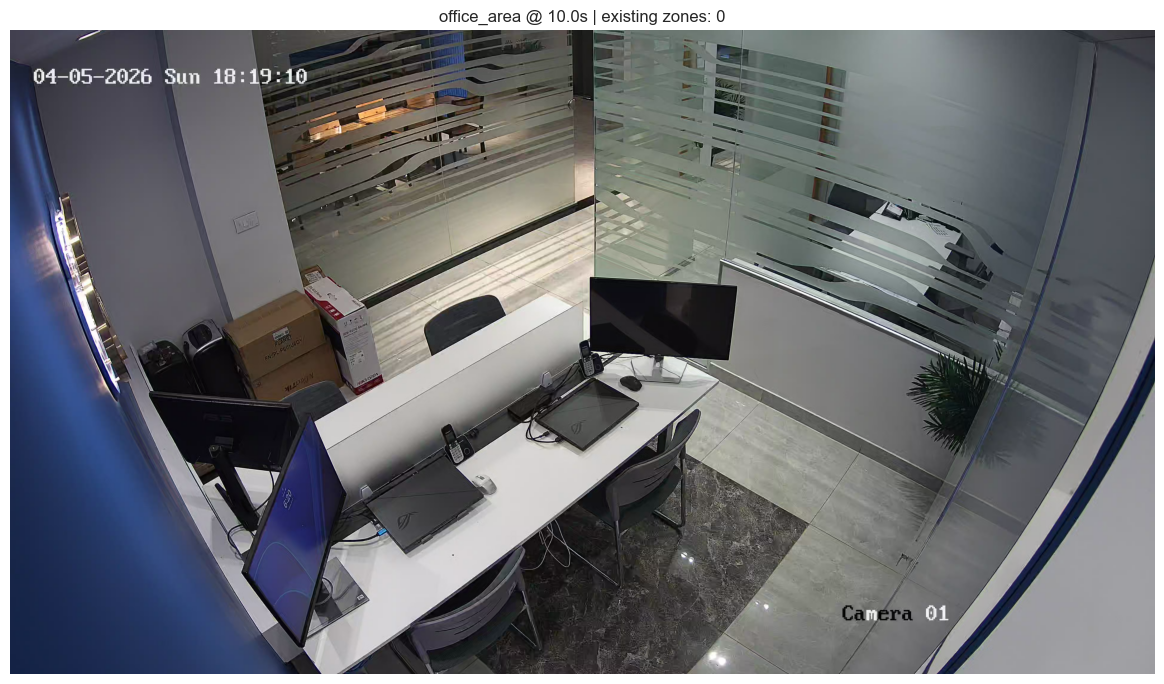


Draw next rectangle (2 clicks)...


In [ ]:
# =========================================================================
# Freeform scene annotator: draw box first, then type zone name.
# =========================================================================
ANNOTATE_SCENE = "office_area"
ANNOTATE_FRAME_AT_SEC = 10.0
START_WITH_EXISTING_SCENE_RECTS = True


def _read_scene_frame(scene_name: str, frame_at_sec: float = 0.0):
    rows = _get_scene_rows_for_drawer()
    match = [r for r in rows if r["scene"] == scene_name]
    if not match:
        raise ValueError(f"Scene '{scene_name}' not found. Available: {[r['scene'] for r in rows]}")

    row = match[0]
    path = row["path"]
    cap = cv2.VideoCapture(str(path))
    fps = cap.get(cv2.CAP_PROP_FPS) or 25.0
    target = int(max(0.0, frame_at_sec) * fps)
    cap.set(cv2.CAP_PROP_POS_FRAMES, target)
    ok, frame = cap.read()
    cap.release()
    if not ok:
        raise RuntimeError(f"Could not read frame from {path}")
    return row, frame


def _render_zone_overlay(rgb_frame: np.ndarray,
                         rects: List[Tuple[str, int, int, int, int]],
                         title: str):
    vis = rgb_frame.copy()
    for i, (name, x1, y1, x2, y2) in enumerate(rects, start=1):
        cv2.rectangle(vis, (x1, y1), (x2, y2), (255, 220, 0), 2)
        cv2.putText(vis, f"{i}:{name}", (x1, max(18, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 220, 0), 2, cv2.LINE_AA)
    plt.figure(figsize=(13, 7))
    plt.imshow(vis)
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def annotate_scene_zones_freeform(scene_name: str,
                                  frame_at_sec: float = 0.0,
                                  start_with_existing: bool = True):
    row, frame = _read_scene_frame(scene_name, frame_at_sec)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    rects: List[Tuple[str, int, int, int, int]] = []
    if start_with_existing and scene_name in SCENE_ZONE_RECTS:
        rects = [(n, int(x1), int(y1), int(x2), int(y2)) for n, x1, y1, x2, y2 in SCENE_ZONE_RECTS[scene_name]]

    print("Instructions:")
    print("  - A frame window will appear.")
    print("  - Click TOP-LEFT then BOTTOM-RIGHT for the next zone rectangle.")
    print("  - After clicks, type zone name in the prompt.")
    print("  - Type 'done' as zone name to finish, or 'undo' to remove last zone.")

    while True:
        _render_zone_overlay(
            rgb,
            rects,
            title=f"{scene_name} @ {frame_at_sec:.1f}s | existing zones: {len(rects)}"
        )

        print("\nDraw next rectangle (2 clicks)...")
        fig, ax = plt.subplots(figsize=(13, 7))
        ax.imshow(rgb)
        ax.set_title(f"{scene_name}: click TL then BR (close figure only after clicks)")
        ax.axis("off")
        plt.tight_layout()
        pts = plt.ginput(2, timeout=-1)
        plt.close(fig)

        if len(pts) < 2:
            cmd = input("No box captured. Type 'done' to finish, Enter to retry: ").strip().lower()
            if cmd == "done":
                break
            continue

        (x1, y1), (x2, y2) = pts
        xa, xb = sorted([int(round(x1)), int(round(x2))])
        ya, yb = sorted([int(round(y1)), int(round(y2))])

        name = input("Zone name (or 'undo' / 'done'): ").strip()
        if not name:
            print("Empty name -> skipped this rectangle.")
            continue

        lname = name.lower()
        if lname == "done":
            break
        if lname == "undo":
            if rects:
                removed = rects.pop()
                print(f"Removed: {removed}")
            else:
                print("Nothing to undo.")
            continue

        rects.append((name, xa, ya, xb, yb))
        print(f"Added: ({name}, {xa}, {ya}, {xb}, {yb})")

    SCENE_ZONE_RECTS[scene_name] = rects
    if scene_name == "office_area":
        OFFICE_DESK_ZONE_RECTS[:] = rects

    print("\nUpdated SCENE_ZONE_RECTS entry:")
    print(f"SCENE_ZONE_RECTS['{scene_name}'] = [")
    for n, x1, y1, x2, y2 in rects:
        print(f"    ('{n}', {x1}, {y1}, {x2}, {y2}),")
    print("]")

    if scene_name == "office_area":
        print("\nUpdated OFFICE_DESK_ZONE_RECTS:")
        print("OFFICE_DESK_ZONE_RECTS = [")
        for n, x1, y1, x2, y2 in rects:
            print(f"    ('{n}', {x1}, {y1}, {x2}, {y2}),")
        print("]")

    final_zones = _zones_from_rects(rects)
    preview_scene_zones(row, final_zones, frame_at_sec=frame_at_sec)
    return rects


annotated_rects = annotate_scene_zones_freeform(
    scene_name=ANNOTATE_SCENE,
    frame_at_sec=ANNOTATE_FRAME_AT_SEC,
    start_with_existing=START_WITH_EXISTING_SCENE_RECTS,
)

# Rebuild scene zones with latest edits
scene_inputs = _get_scene_rows_for_drawer()
scene_zones = build_scene_zones(scene_inputs, SCENE_ZONE_RECTS)
print("\nscene_zones rebuilt with freeform annotations.")


### Reliable fallback: native ROI selector (OpenCV window)

If matplotlib clicking does not work in your notebook backend, use this cell.
It opens a native OpenCV window where you can draw multiple rectangles.

Controls in OpenCV ROI window:

- drag mouse to draw a rectangle
- press **Enter** or **Space** to confirm current rectangle
- press **c** to cancel current rectangle
- when done with all rectangles, press **Esc** to finish

After selection, the cell asks you to name each rectangle and updates
`SCENE_ZONE_RECTS` (and `OFFICE_DESK_ZONE_RECTS` for `office_area`).


In [ ]:
# =========================================================================
# Native OpenCV ROI selector (fallback when matplotlib clicks fail)
# =========================================================================
ROI_SCENE = "office_area"
ROI_FRAME_AT_SEC = 10.0
WINDOW_NAME = "Draw zones - Enter/Space: accept box, Esc: finish"


def annotate_scene_zones_with_cv2(scene_name: str, frame_at_sec: float = 0.0):
    row, frame = _read_scene_frame(scene_name, frame_at_sec)
    # OpenCV expects BGR (already BGR from cv2 capture)
    canvas = frame.copy()

    print("OpenCV ROI selector instructions:")
    print("  1) Drag to draw rectangle")
    print("  2) Enter/Space accepts rectangle")
    print("  3) Esc finishes all selections")
    print("  4) c cancels current drag")

    rois = cv2.selectROIs(WINDOW_NAME, canvas, showCrosshair=True, fromCenter=False)
    cv2.destroyWindow(WINDOW_NAME)

    if rois is None or len(rois) == 0:
        print("No rectangles selected.")
        return []

    rects = []
    print(f"Selected {len(rois)} rectangle(s). Please name each one:")
    for i, (x, y, w, h) in enumerate(rois, start=1):
        if w <= 1 or h <= 1:
            continue
        default_name = f"zone_{i}"
        name = input(f"Name for box {i} [default: {default_name}]: ").strip() or default_name
        x1, y1, x2, y2 = int(x), int(y), int(x + w), int(y + h)
        rects.append((name, x1, y1, x2, y2))

    SCENE_ZONE_RECTS[scene_name] = rects
    if scene_name == "office_area":
        OFFICE_DESK_ZONE_RECTS[:] = rects

    print("\nUpdated SCENE_ZONE_RECTS entry:")
    print(f"SCENE_ZONE_RECTS['{scene_name}'] = [")
    for n, x1, y1, x2, y2 in rects:
        print(f"    ('{n}', {x1}, {y1}, {x2}, {y2}),")
    print("]")

    if scene_name == "office_area":
        print("\nUpdated OFFICE_DESK_ZONE_RECTS:")
        print("OFFICE_DESK_ZONE_RECTS = [")
        for n, x1, y1, x2, y2 in rects:
            print(f"    ('{n}', {x1}, {y1}, {x2}, {y2}),")
        print("]")

    # Preview result
    zones = _zones_from_rects(rects)
    preview_scene_zones(row, zones, frame_at_sec=frame_at_sec)

    # Rebuild scene_zones for immediate use
    scene_rows = _get_scene_rows_for_drawer()
    new_scene_zones = build_scene_zones(scene_rows, SCENE_ZONE_RECTS)
    return rects, new_scene_zones


roi_rects, scene_zones = annotate_scene_zones_with_cv2(
    scene_name=ROI_SCENE,
    frame_at_sec=ROI_FRAME_AT_SEC,
)


## 7.5 — Diagnosis & calibration

The cell below is a self-contained debugger that helps answer two questions:

1. **What is the detector / tracker actually seeing?** It samples evenly-spaced
   frames from a chosen video, runs YOLOv8, and renders the boxes + class +
   confidence on a montage so you can eyeball whether the detector is healthy.
2. **Why are people being labelled `UNKNOWN`?** For every person crop in the
   sample it computes the *raw* cosine similarity against every gallery entry
   — both face (ArcFace) and body (OSNet ReID) — and prints them as a table.
   That tells you exactly where each crop sits relative to `FACE_MATCH_THR` /
   `REID_MATCH_THR`, so you can pick thresholds with data instead of guessing.

After the table, a recommendations block summarises common failure modes
(no face ever detected, ReID similarities chronically below threshold, gallery
too small) and prints concrete next steps.


Scanning Camera_01_NVR_20260405181900_20260405182017_633282.mp4: 1551 frames @ 20.0 fps (stride=5, conf=0.2) ...


[hevc @ 0x325c9cd30] Could not find ref with POC 3
[hevc @ 0x325c9cd30] Could not find ref with POC 8
[hevc @ 0x325c9cd30] Could not find ref with POC 12
[hevc @ 0x325c9cd30] Could not find ref with POC 17
[hevc @ 0x325c9cd30] Could not find ref with POC 23
[hevc @ 0x325c9cd30] Could not find ref with POC 28
[hevc @ 0x325c9cd30] Could not find ref with POC 32
[hevc @ 0x325c9cd30] Could not find ref with POC 37
[hevc @ 0x325c9cd30] Could not find ref with POC 43
[hevc @ 0x325c9cd30] Could not find ref with POC 48
[hevc @ 0x325c9cd30] Could not find ref with POC 2
[hevc @ 0x325c9cd30] Could not find ref with POC 7
[hevc @ 0x325c9cd30] Could not find ref with POC 13
[hevc @ 0x325c9cd30] Could not find ref with POC 18
[hevc @ 0x325c9cd30] Could not find ref with POC 22
[hevc @ 0x325c9cd30] Could not find ref with POC 27
[hevc @ 0x325c9cd30] Could not find ref with POC 33
[hevc @ 0x325c9cd30] Could not find ref with POC 38
[hevc @ 0x325c9cd30] Could not find ref with POC 42
[hevc @ 0x325c9c

  found 8 frames containing a person (scanned 675/1551 frames).

=== (a) detection sanity (per sampled frame) ===
 frame  t_s  people  phones  laptops
    80  4.0       3       0        0
    85  4.2       1       0        0
    90  4.5       1       0        0
   320 16.0       1       0        0
   325 16.2       1       0        0
   330 16.5       1       0        0
   445 22.2       1       0        0
   670 33.5       1       0        0


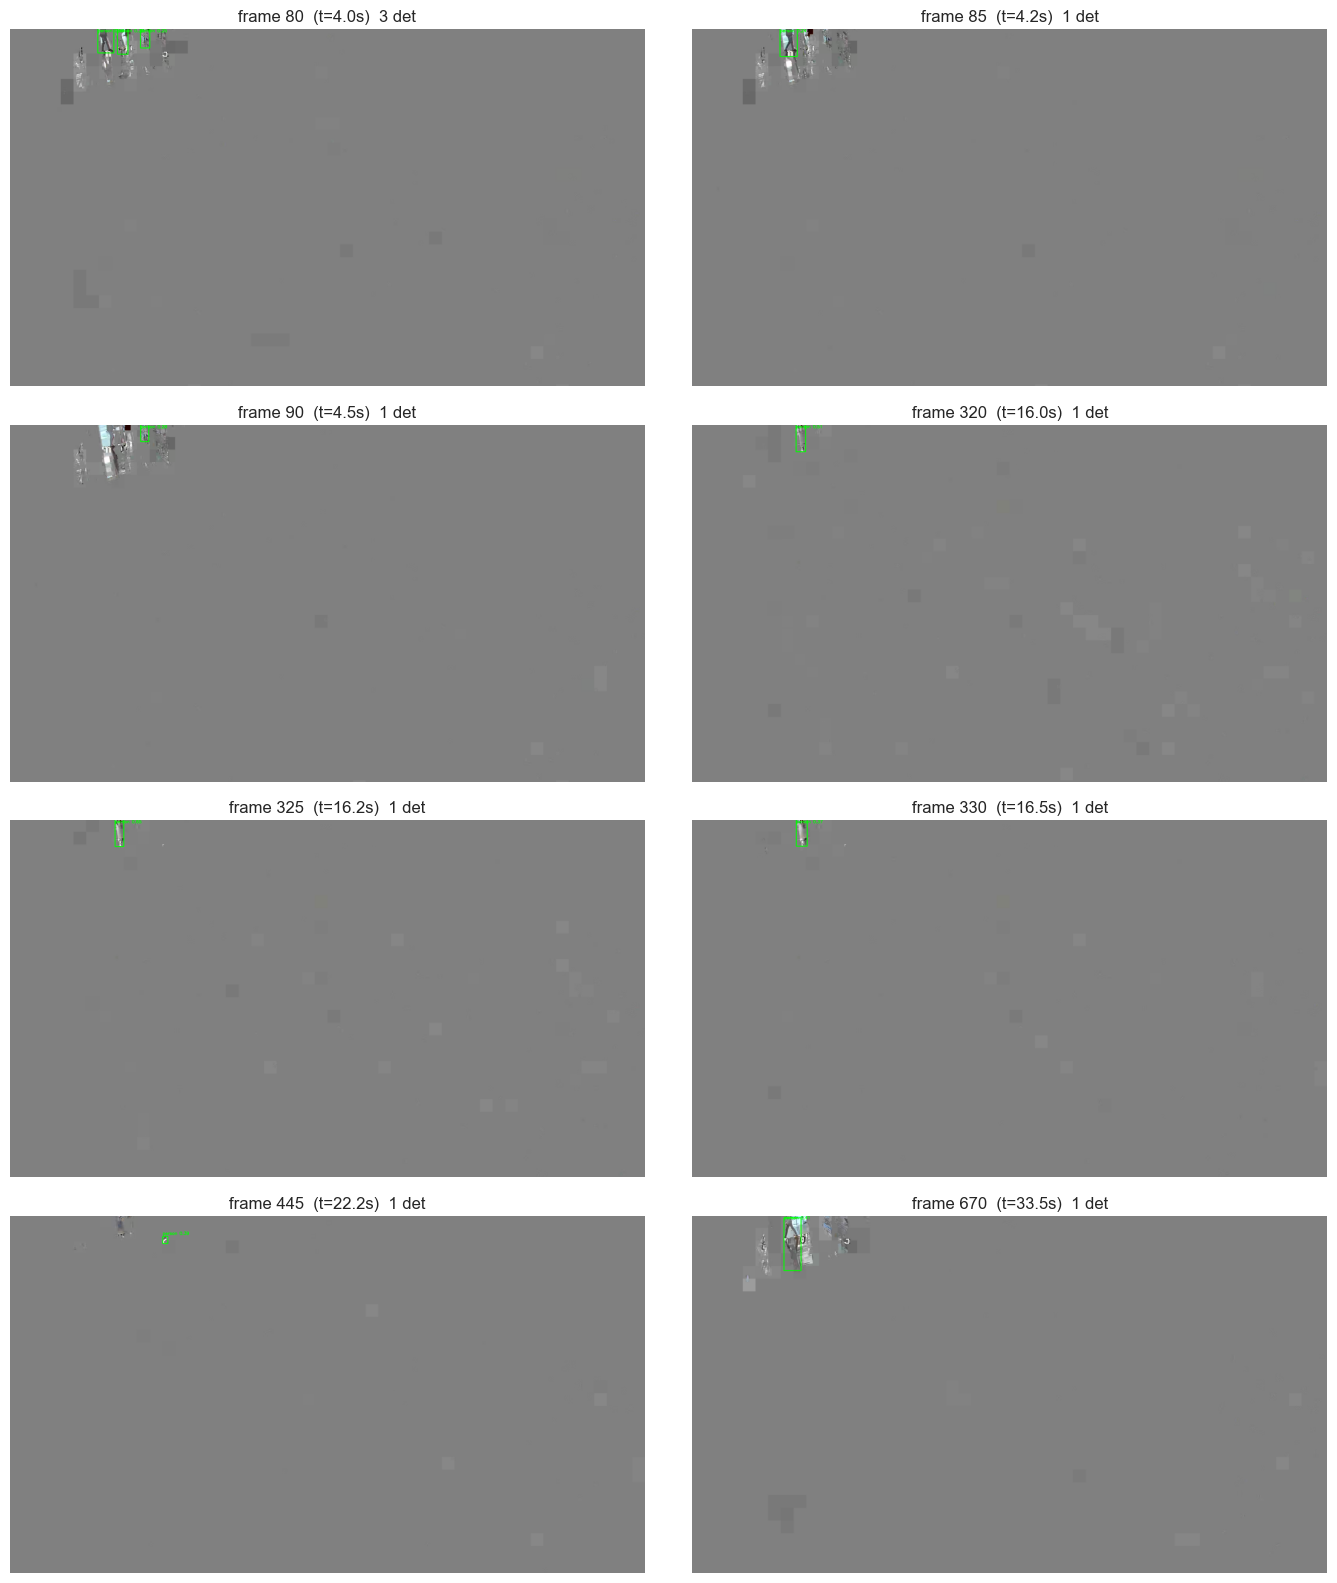


=== (b) identity diagnosis (raw cosine similarities per crop) ===
 frame crop_hw  face_det face·hasan  reid·hasan face·majd  reid·majd
    80  125x81     False       None       0.449      None      0.505
    80  131x53     False       None       0.518      None      0.519
    80   98x47     False       None       0.480      None      0.467
    85  143x87     False       None       0.546      None      0.595
    90   88x41     False       None       0.486      None      0.438
   320  139x48     False       None       0.425      None      0.448
   325  137x44     False       None       0.427      None      0.475
   330  135x55     False       None       0.450      None      0.455
   445   36x26     False       None       0.459      None      0.469
   670  265x86     False       None       0.481      None      0.524

  thresholds in use: FACE_MATCH_THR=0.4  REID_MATCH_THR=0.55

=== (c) gallery summary ===
  hasan                 face_vec_norm=1.00  reid_vecs=12
  majd                  fa

In [49]:
# =========================================================================
# Diagnostic cell — run this whenever the pipeline produces unexpected output.
# Configure the knobs below, then execute.
# =========================================================================
SAMPLE_VIDEO    = sorted(DATA_DIR.glob("*.mp4"))[0]    # which clip to inspect
N_SAMPLE_FRAMES = 8                                    # how many populated frames we want
SCAN_STRIDE     = 5                                    # step between candidate frames during scan
DEBUG_DET_CONF  = 0.20                                 # use a permissive conf for diagnosis only

# ----- (0) scan the video for frames that actually contain a person ------
# Surveillance footage is mostly empty, so blindly sampling with linspace can
# miss every person. Instead we walk through the clip with a coarse stride
# and keep the first N_SAMPLE_FRAMES frames where YOLO finds >= 1 person at
# DEBUG_DET_CONF. If we exhaust the clip without finding enough, we pad with
# empty frames so the montage still tells us something.
det = monitor.detector if "monitor" in dir() else PersonObjectDetector()

cap     = cv2.VideoCapture(str(SAMPLE_VIDEO))
n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps_v   = cap.get(cv2.CAP_PROP_FPS) or 25.0

records   = []   # frames with people
empty_pad = []   # fallback empty frames (kept in case we don't find enough)
fi = 0
print(f"Scanning {SAMPLE_VIDEO.name}: {n_total} frames @ {fps_v:.1f} fps "
      f"(stride={SCAN_STRIDE}, conf={DEBUG_DET_CONF}) ...")

while fi < n_total and len(records) < N_SAMPLE_FRAMES:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(fi))
    ok, frame = cap.read()
    if not ok:
        break
    res = det.model.predict(frame, conf=DEBUG_DET_CONF, iou=DET_IOU, verbose=False)[0]
    dets = []
    if res.boxes is not None and len(res.boxes):
        xyxy = res.boxes.xyxy.cpu().numpy().astype(int)
        conf = res.boxes.conf.cpu().numpy()
        cls  = res.boxes.cls.cpu().numpy().astype(int)
        for b, c, k in zip(xyxy, conf, cls):
            if int(k) not in det.keep:
                continue
            dets.append(dict(bbox=b, conf=float(c), cls_id=int(k),
                             cls_name=TARGET_CLASSES[int(k)]))

    has_person = any(d["cls_name"] == "person" for d in dets)
    vis = frame.copy()
    for d in dets:
        x1, y1, x2, y2 = d["bbox"]
        col = (0, 255, 0) if d["cls_name"] == "person" else (0, 180, 255)
        cv2.rectangle(vis, (x1, y1), (x2, y2), col, 3)
        cv2.putText(vis, f"{d['cls_name']} {d['conf']:.2f}",
                    (x1, max(20, y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, col, 2)
    rec = dict(fi=fi, frame=frame, vis=vis, dets=dets)
    if has_person:
        records.append(rec)
    elif len(empty_pad) < N_SAMPLE_FRAMES:
        empty_pad.append(rec)
    fi += SCAN_STRIDE

cap.release()

if not records:
    print("  (no person in any sampled frame at the diagnostic conf threshold)")
    print("  → showing empty-scene samples instead so you can verify YOLO isn't crashing.")
    records = empty_pad[:N_SAMPLE_FRAMES]
else:
    print(f"  found {len(records)} frames containing a person "
          f"(scanned {fi}/{n_total} frames).")

# ----- (a) detection-counts table ----------------------------------------
print("\n=== (a) detection sanity (per sampled frame) ===")
summary = pd.DataFrame([
    dict(frame=r["fi"], t_s=round(r["fi"] / fps_v, 1),
         people =sum(1 for d in r["dets"] if d["cls_name"] == "person"),
         phones =sum(1 for d in r["dets"] if d["cls_name"] == "cell phone"),
         laptops=sum(1 for d in r["dets"] if d["cls_name"] == "laptop"))
    for r in records
])
print(summary.to_string(index=False))

# ----- montage of annotated frames ---------------------------------------
cols  = 2
rows_ = max(1, math.ceil(len(records) / cols))
fig, axes = plt.subplots(rows_, cols, figsize=(14, 4 * rows_))
axes_flat = np.atleast_1d(axes).flatten()
for ax, r in zip(axes_flat, records):
    ax.imshow(cv2.cvtColor(r["vis"], cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {r['fi']}  (t={r['fi']/fps_v:.1f}s)  "
                 f"{len(r['dets'])} det")
    ax.axis("off")
for ax in axes_flat[len(records):]:
    ax.axis("off")
plt.tight_layout(); plt.show()

# ----- (b) identity diagnosis: raw cosine sims to gallery ----------------
gallery_path = GALLERY_DIR / "gallery.npz"
if not gallery_path.exists():
    print("\n no gallery yet — see Section 3.3 to enroll employees.")
else:
    gal      = EmployeeGallery.load(gallery_path)
    face_emb = monitor.face_emb if "monitor" in dir() else FaceEmbedder()
    reid_emb = monitor.reid_emb if "monitor" in dir() else ReIDEmbedder()

    # Ignore stale/helper identities with no usable vectors.
    active_names = []
    for i, name in enumerate(gal.names):
        has_face = float(np.linalg.norm(gal.face_vecs[i])) > 1e-6
        has_reid = gal.reid_banks.get(name, np.zeros((0, 512), np.float32)).size > 0
        if has_face or has_reid:
            active_names.append(name)

    if len(active_names) != len(gal.names):
        dropped = [n for n in gal.names if n not in active_names]
        print("Ignoring empty gallery identities:", ", ".join(dropped))

    name_to_idx = {n: i for i, n in enumerate(gal.names)}

    print("\n=== (b) identity diagnosis (raw cosine similarities per crop) ===")
    diag_rows = []
    for r in records:
        H, W = r["frame"].shape[:2]
        for d in r["dets"]:
            if d["cls_name"] != "person":
                continue
            x1, y1, x2, y2 = d["bbox"]
            x1, y1 = max(0, x1), max(0, y1)
            x2, y2 = min(W, x2), min(H, y2)
            crop = r["frame"][y1:y2, x1:x2]
            if crop.size == 0:
                continue
            face_v = face_emb.embed(crop)
            reid_v = reid_emb.embed(crop)
            row = dict(frame=r["fi"], crop_hw=f"{crop.shape[0]}x{crop.shape[1]}",
                       face_det=face_v is not None)
            for name in active_names:
                i = name_to_idx[name]
                row[f"face·{name}"] = (round(float(face_v @ gal.face_vecs[i]), 3)
                                       if face_v is not None else None)
                bank = gal.reid_banks.get(name, np.zeros((0, 512), np.float32))
                row[f"reid·{name}"] = (round(float(np.max(bank @ reid_v)), 3)
                                       if bank.size else None)
            diag_rows.append(row)

    diag = pd.DataFrame(diag_rows)
    if diag.empty:
        print("  (no person detections in sampled frames — drop DET_CONF and re-run)")
    else:
        with pd.option_context("display.max_rows", None,
                               "display.max_columns", None,
                               "display.width", 200):
            print(diag.to_string(index=False))
        print(f"\n  thresholds in use: FACE_MATCH_THR={FACE_MATCH_THR}  "
              f"REID_MATCH_THR={REID_MATCH_THR}")

    # ----- (c) gallery summary --------------------------------------------
    print("\n=== (c) gallery summary ===")
    for name in active_names:
        i = name_to_idx[name]
        face_norm = float(np.linalg.norm(gal.face_vecs[i]))
        n_reid    = gal.reid_banks.get(name, np.zeros((0, 512), np.float32)).shape[0]
        print(f"  {name:20s}  face_vec_norm={face_norm:.2f}  reid_vecs={n_reid}")

    # ----- (d) recommendations --------------------------------------------
    print("\n=== (d) recommendations ===")
    if not diag.empty:
        n_face_det = int(diag["face_det"].sum())
        n_total    = len(diag)
        print(f"  faces detected in person crops: {n_face_det}/{n_total}")
        if n_face_det == 0:
            print("    • Face detector never found a face. Likely the camera is too far or")
            print("      the angle is too steep for ArcFace. Options:")
            print("        (i)  enroll more face refs and lower FACE_MATCH_THR to ~0.35")
            print("        (ii) accept face fallback failure and rely on ReID")
        reid_cols = [c for c in diag.columns if c.startswith("reid·")]
        if reid_cols:
            best_reid = diag[reid_cols].max(axis=1).dropna()
            if not best_reid.empty:
                print(f"  best ReID similarity per crop: "
                      f"min={best_reid.min():.3f}  median={best_reid.median():.3f}  "
                      f"max={best_reid.max():.3f}")
                if best_reid.median() < REID_MATCH_THR:
                    print(f"    • Median best-match is below REID_MATCH_THR "
                          f"({REID_MATCH_THR}).")
                    print("      → Drop REID_MATCH_THR to roughly best_reid.median()-0.05,")
                    print("        OR enroll 10+ body crops *from this same camera*.")
        per_person = {
            n: gal.reid_banks.get(n, np.zeros((0, 512), np.float32)).shape[0]
            for n in active_names
        }
        if per_person and any(v < 5 for v in per_person.values()):
            print("  • Gallery is sparse (< 5 ReID vectors per person). Strongly recommend")
            print("    capturing 10+ body crops varying pose / orientation per employee.")


### 7.6 — Bootstrap enrollment from this camera

The diagnostic above showed that the gallery's single off-camera body image
gives ReID similarities indistinguishable from the noise floor (~0.4) on the
in-video crops. The fix isn't a threshold tweak — it's better reference data.

The cell below **harvests body crops directly from this video**: it runs
YOLOv8 + ByteTrack, groups crops by `track_id`, and saves the top-K
highest-confidence crops per track to:

```
gallery/_harvest/track_<id>/body/*.jpg
```

After running it, open that folder in Finder, look at each `track_<id>/body`
directory, identify which track is which employee, then **rename the folder**
from `track_<id>` to the employee's name (`hasan`, `majd`, etc.). Move it up
one level so it sits next to the existing per-employee folders, and re-run
the gallery-builder cell. The new gallery will have ~`HARVEST_TOP_K` body
vectors per person captured from the same camera, in similar lighting and
pose distribution to the video — which is the regime ReID is good at.

If you also want a face-channel signal, the same crops can be inspected for
the rare frames where a face is large enough; in surveillance scenes that's
typically only when someone walks toward the camera, so don't expect a high
yield.


Harvesting Camera_01_NVR_20260405181900_20260405182017_633282.mp4: 1551 frames @ 20.0 fps (stride=5, top 12 crops/track)


harvest:  84%|████████▎ | 259/310 [01:45<00:25,  2.03it/s]harvest:  91%|█████████ | 281/310 [02:01<00:25,  1.14it/s]harvest: 100%|█████████▉| 309/310 [02:18<00:00,  2.58it/s]

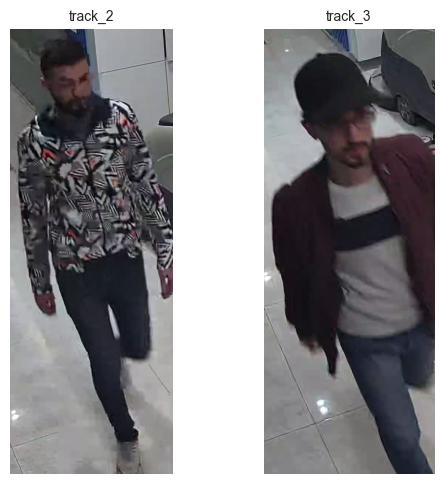


Next steps:
  1. Open /Users/omarkhairat/University/graduation project/gallery/_harvest and inspect each track_<id>/body/ folder.
  2. For each track that corresponds to a real employee, rename the
     folder from track_<id> to that employee's name (e.g. 'hasan').
  3. Move the renamed folders up one level into /Users/omarkhairat/University/graduation project/gallery/
     (they will replace your existing 1-image-per-person gallery).
  4. Re-run the gallery-builder cell (Section 3.3) and then the demo run.


In [39]:
# =========================================================================
# Harvest per-track body crops from one of the videos to bootstrap the gallery.
# =========================================================================
HARVEST_VIDEO   = sorted(DATA_DIR.glob("*.mp4"))[0]   # which clip to harvest
HARVEST_STRIDE  = 5                                   # process every Nth frame
HARVEST_TOP_K   = 12                                  # crops to keep per track
HARVEST_MIN_AREA = 60 * 30                            # px²; ignore tiny crops
HARVEST_DIR      = GALLERY_DIR / "_harvest"

# We need a fresh detector for this — calling .track() on the existing
# `monitor.detector` would interleave its ByteTrack state with the live demo.
harvest_det = PersonObjectDetector()

cap = cv2.VideoCapture(str(HARVEST_VIDEO))
n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps_h   = cap.get(cv2.CAP_PROP_FPS) or 25.0
print(f"Harvesting {HARVEST_VIDEO.name}: {n_total} frames @ {fps_h:.1f} fps "
      f"(stride={HARVEST_STRIDE}, top {HARVEST_TOP_K} crops/track)")

# track_id -> list of (conf, frame_idx, crop_bgr), kept sorted desc by conf.
import heapq
buckets: Dict[int, list] = collections.defaultdict(list)

fi, processed = 0, 0
pbar = tqdm(total=n_total // HARVEST_STRIDE, desc="harvest")
while True:
    ok, frame = cap.read()
    if not ok:
        break
    if fi % HARVEST_STRIDE != 0:
        fi += 1
        continue
    fi += 1
    processed += 1
    pbar.update(1)
    H, W = frame.shape[:2]

    dets = harvest_det.track(frame)
    for d in dets:
        if d["cls_name"] != "person":
            continue
        x1, y1, x2, y2 = d["bbox"]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(W, x2), min(H, y2)
        if (x2 - x1) * (y2 - y1) < HARVEST_MIN_AREA:
            continue
        crop = frame[y1:y2, x1:x2].copy()
        if crop.size == 0:
            continue
        bucket = buckets[d["track_id"]]
        if len(bucket) < HARVEST_TOP_K:
            heapq.heappush(bucket, (d["conf"], processed, crop))
        elif d["conf"] > bucket[0][0]:
            heapq.heapreplace(bucket, (d["conf"], processed, crop))
pbar.close(); cap.release()

# ----- Filter out short-lived tracks (likely noise) ---------------------
MIN_CROPS_PER_TRACK = 5
viable = {tid: b for tid, b in buckets.items() if len(b) >= MIN_CROPS_PER_TRACK}
print(f"\nFound {len(buckets)} tracks total, "
      f"{len(viable)} with >= {MIN_CROPS_PER_TRACK} crops kept.")

# ----- Save crops to disk -----------------------------------------------
if HARVEST_DIR.exists():
    import shutil; shutil.rmtree(HARVEST_DIR)
HARVEST_DIR.mkdir(parents=True, exist_ok=True)

manifest_rows = []
for tid, bucket in sorted(viable.items()):
    body_dir = HARVEST_DIR / f"track_{tid:03d}" / "body"
    body_dir.mkdir(parents=True, exist_ok=True)
    # save high-conf crops first
    for rank, (conf, pframe, crop) in enumerate(sorted(bucket, key=lambda x: -x[0])):
        out = body_dir / f"{rank:02d}_pframe{pframe:05d}_conf{conf:.2f}.jpg"
        cv2.imwrite(str(out), crop)
    manifest_rows.append(dict(track_id=tid, n_crops=len(bucket),
                              best_conf=round(max(b[0] for b in bucket), 3),
                              folder=str(body_dir.parent.relative_to(PROJECT_DIR))))

print("\n=== harvested tracks ===")
print(pd.DataFrame(manifest_rows).to_string(index=False))

# ----- Show a montage of best crop per track for quick identification ---
if viable:
    cols   = min(4, len(viable))
    rows_  = max(1, math.ceil(len(viable) / cols))
    fig, axes = plt.subplots(rows_, cols, figsize=(3 * cols, 5 * rows_))
    axes_flat = np.atleast_1d(axes).flatten()
    for ax, (tid, bucket) in zip(axes_flat, sorted(viable.items())):
        best = max(bucket, key=lambda x: x[0])[2]
        ax.imshow(cv2.cvtColor(best, cv2.COLOR_BGR2RGB))
        ax.set_title(f"track_{tid}", fontsize=10)
        ax.axis("off")
    for ax in axes_flat[len(viable):]:
        ax.axis("off")
    plt.tight_layout(); plt.show()

print("\nNext steps:")
print(f"  1. Open {HARVEST_DIR} and inspect each track_<id>/body/ folder.")
print("  2. For each track that corresponds to a real employee, rename the")
print("     folder from track_<id> to that employee's name (e.g. 'hasan').")
print(f"  3. Move the renamed folders up one level into {GALLERY_DIR}/")
print("     (they will replace your existing 1-image-per-person gallery).")
print("  4. Re-run the gallery-builder cell (Section 3.3) and then the demo run.")


### 7.7 — Gallery sanity check (label leakage / separability)

Use this cell before changing thresholds further. It verifies whether the ReID
vectors currently stored in `gallery.npz` are actually separable by identity.

Outputs:

1. **Numerical separability report**
   - mean intra-class cosine per employee (`same person`)
   - mean inter-class cosine across employees (`different people`)
   - the key signal: `intra - inter` gap
2. **Heatmap** of all-vs-all cosine similarities across gallery vectors.
   A healthy gallery shows a block-diagonal pattern.
3. **Thumbnail grids** from each employee's `body/` folder so you can visually
   confirm that labels are not mixed.

Interpretation rule of thumb:

- gap >= 0.15: good separation
- 0.05 <= gap < 0.15: weak / noisy
- gap < 0.05: likely contaminated gallery (or identities too similar for current model)


Loaded gallery: /Users/omarkhairat/University/graduation project/gallery/gallery.npz
Employees: ['_harvest', 'hasan', 'majd']

=== separability report ===
employee  n_vecs  intra_mean  intra_std
_harvest       0         NaN        NaN
   hasan      12    0.755425   0.078411
    majd      12    0.777977   0.077134

inter_mean=0.6014  inter_std=0.0562
mean(intra_mean) - inter_mean = 0.1653
Assessment: GOOD separation.


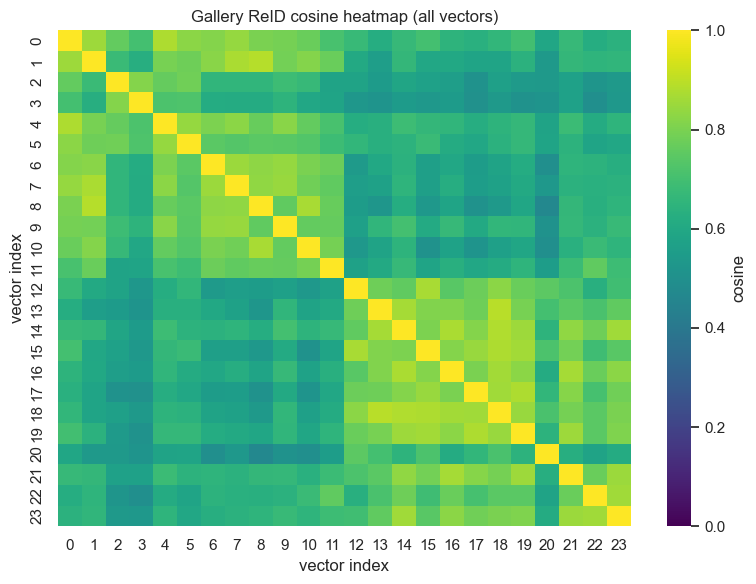


=== vector index ranges by employee ===
hasan               : [ 0, 11]  (n=12)
majd                : [12, 23]  (n=12)

_harvest: 0 body images in /Users/omarkhairat/University/graduation project/gallery/_harvest/body

hasan: 12 body images in /Users/omarkhairat/University/graduation project/gallery/hasan/body


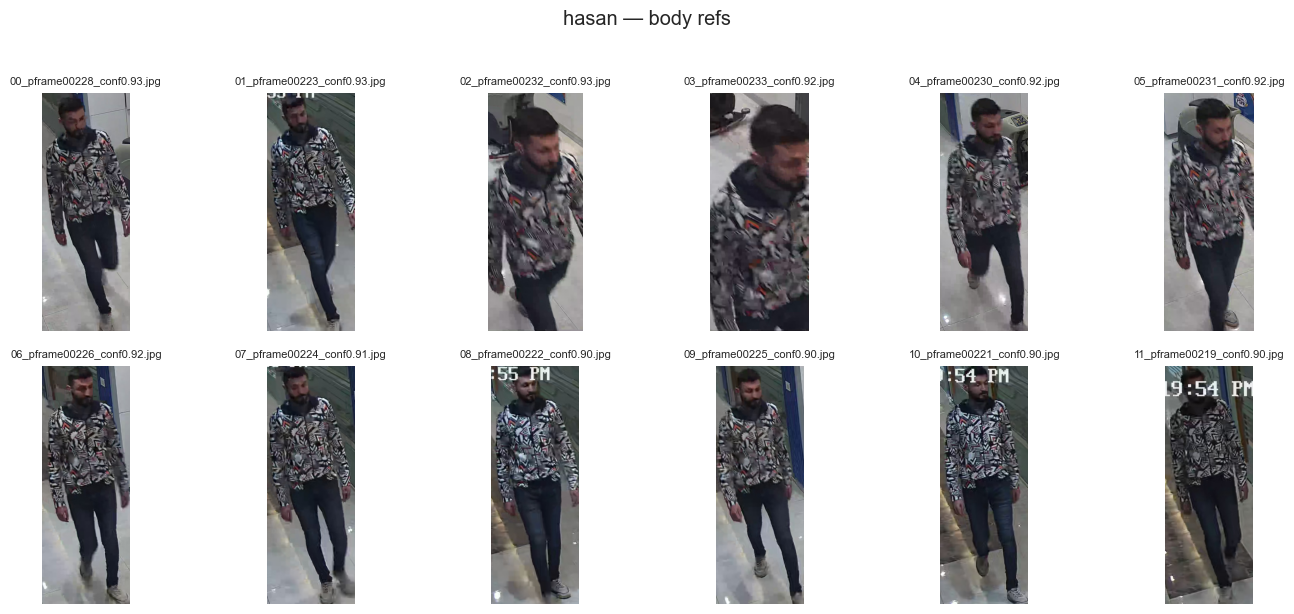

In [ ]:
# =========================================================================
# Gallery sanity-check: quantify separability + visually inspect body crops.
# =========================================================================
gallery_path = GALLERY_DIR / "gallery.npz"
if not gallery_path.exists():
    raise FileNotFoundError(f"Missing gallery file: {gallery_path}")

gal = EmployeeGallery.load(gallery_path)
print(f"Loaded gallery: {gallery_path}")
print(f"Employees: {gal.names}")

# ----- 1) Intra / inter cosine report -------------------------------------
def _pairwise_cos(X: np.ndarray) -> np.ndarray:
    # X is assumed L2-normalized row-wise by upstream pipeline.
    return X @ X.T

def _offdiag_values(M: np.ndarray) -> np.ndarray:
    if M.size == 0:
        return np.array([], dtype=np.float32)
    mask = ~np.eye(M.shape[0], dtype=bool)
    return M[mask]

# pack all vectors for global heatmap
all_vecs = []
labels = []
for name in gal.names:
    bank = gal.reid_banks.get(name, np.zeros((0, 512), np.float32))
    if bank.size == 0:
        continue
    all_vecs.append(bank)
    labels.extend([name] * bank.shape[0])

if not all_vecs:
    raise RuntimeError("No ReID vectors found in gallery banks.")

V = np.vstack(all_vecs)
S = _pairwise_cos(V)

# per-employee intra stats
rows = []
for name in gal.names:
    bank = gal.reid_banks.get(name, np.zeros((0, 512), np.float32))
    if bank.shape[0] < 2:
        rows.append(dict(employee=name, n_vecs=bank.shape[0], intra_mean=np.nan, intra_std=np.nan))
        continue
    m = _pairwise_cos(bank)
    vals = _offdiag_values(m)
    rows.append(dict(employee=name,
                     n_vecs=bank.shape[0],
                     intra_mean=float(np.mean(vals)),
                     intra_std=float(np.std(vals))))
intra_df = pd.DataFrame(rows)

# inter stats across different employees
inter_vals = []
for i, a in enumerate(gal.names):
    A = gal.reid_banks.get(a, np.zeros((0, 512), np.float32))
    if A.size == 0:
        continue
    for b in gal.names[i + 1:]:
        B = gal.reid_banks.get(b, np.zeros((0, 512), np.float32))
        if B.size == 0:
            continue
        inter_vals.append((A @ B.T).reshape(-1))
if inter_vals:
    inter_vals = np.concatenate(inter_vals)
    inter_mean = float(np.mean(inter_vals))
    inter_std = float(np.std(inter_vals))
else:
    inter_mean = np.nan
    inter_std = np.nan

print("\n=== separability report ===")
print(intra_df.to_string(index=False))
print(f"\ninter_mean={inter_mean:.4f}  inter_std={inter_std:.4f}")

valid_intra = intra_df["intra_mean"].dropna().values
if len(valid_intra):
    gap = float(np.mean(valid_intra) - inter_mean)
    print(f"mean(intra_mean) - inter_mean = {gap:.4f}")
    if gap >= 0.15:
        print("Assessment: GOOD separation.")
    elif gap >= 0.05:
        print("Assessment: WEAK separation (likely noisy labels / hard viewpoint).")
    else:
        print("Assessment: BROKEN separation (likely gallery contamination).")

# ----- 2) Heatmap of all-vs-all gallery cosines ---------------------------
plt.figure(figsize=(8, 6))
ax = sns.heatmap(S, cmap="viridis", vmin=0.0, vmax=1.0, cbar_kws={"label": "cosine"})
ax.set_title("Gallery ReID cosine heatmap (all vectors)")
ax.set_xlabel("vector index")
ax.set_ylabel("vector index")
plt.tight_layout(); plt.show()

# show block boundaries by name
label_arr = np.array(labels)
print("\n=== vector index ranges by employee ===")
start = 0
for name in gal.names:
    n = int(np.sum(label_arr == name))
    if n > 0:
        print(f"{name:20s}: [{start:2d}, {start+n-1:2d}]  (n={n})")
        start += n

# ----- 3) Thumbnail sanity-check from body folders ------------------------
# This catches accidental label swaps that vectors alone may hide.
MAX_THUMBS = 12
for name in gal.names:
    body_dir = GALLERY_DIR / name / "body"
    imgs = sorted(list(body_dir.glob("*.jpg")) + list(body_dir.glob("*.png")) + list(body_dir.glob("*.jpeg")))
    print(f"\n{name}: {len(imgs)} body images in {body_dir}")
    if not imgs:
        continue
    show = imgs[:MAX_THUMBS]
    cols = min(6, len(show))
    rows = int(math.ceil(len(show) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(2.4 * cols, 3.0 * rows))
    axes_flat = np.atleast_1d(axes).flatten()
    for ax, p in zip(axes_flat, show):
        im = cv2.imread(str(p))
        if im is None:
            ax.set_title("(read fail)", fontsize=8)
            ax.axis("off")
            continue
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
        ax.set_title(p.name, fontsize=8)
        ax.axis("off")
    for ax in axes_flat[len(show):]:
        ax.axis("off")
    fig.suptitle(f"{name} — body refs", y=1.02)
    plt.tight_layout(); plt.show()


## 8. Evaluation, timelines & dashboards

With `events_df` in hand we can visualise a workday. Three views help the most:

1. **Timeline Gantt** — one coloured bar per event, stacked per employee. Instantly shows
   who was at their desk and who drifted.
2. **Daily totals** — a grouped bar chart of total seconds per (employee, event_type).
3. **Interaction graph** — a network diagram where nodes are employees and edges are
   minutes spent interacting. Useful to spot the social hub of the office.

If you have ground-truth labels (a small CSV of events hand-annotated by you), the
`evaluate()` helper reports the standard MOT-style metrics (Precision / Recall / IDF1 /
MOTA) by joining predicted vs true events on `(employee_id, overlapping time window)`.


In [ ]:
def plot_timeline(events_df: pd.DataFrame, title="Activity timeline"):
    if events_df.empty:
        print("No events to plot."); return
    types  = events_df["event_type"].unique().tolist()
    cmap   = {t: c for t, c in zip(types, sns.color_palette("tab10", n_colors=len(types)))}
    emps   = events_df["employee_id"].unique().tolist()
    y      = {e: i for i, e in enumerate(emps)}
    fig, ax = plt.subplots(figsize=(12, 0.6 * len(emps) + 2))
    for _, r in events_df.iterrows():
        ax.barh(y[r["employee_id"]], width=r["duration_s"], left=r["start_s"],
                height=0.55, color=cmap[r["event_type"]], edgecolor="black", lw=0.2,
                label=r["event_type"])
    handles = [plt.Rectangle((0,0),1,1, color=cmap[t]) for t in types]
    ax.legend(handles, types, loc="upper right", ncol=len(types))
    ax.set_yticks(list(y.values())); ax.set_yticklabels(list(y.keys()))
    ax.set_xlabel("time (s)"); ax.set_title(title)
    plt.tight_layout(); plt.show()


def plot_totals(events_df: pd.DataFrame):
    if events_df.empty:
        print("No events to plot."); return
    totals = (events_df.groupby(["employee_id","event_type"])["duration_s"]
                       .sum().reset_index())
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.barplot(data=totals, x="employee_id", y="duration_s",
                hue="event_type", ax=ax)
    ax.set_ylabel("seconds"); ax.set_title("Total activity per employee")
    plt.tight_layout(); plt.show()


def plot_interaction_graph(events_df: pd.DataFrame):
    inter = events_df[events_df["event_type"] == "interaction"]
    if inter.empty:
        print("No interaction events."); return
    try:
        import networkx as nx
    except ImportError:
        print("pip install networkx for interaction graph"); return
    G = nx.Graph()
    for _, r in inter.iterrows():
        a, b = r["peers"] if "peers" in r and isinstance(r["peers"], tuple) \
               else r["employee_id"].split(" <-> ")
        G.add_edge(a, b, weight=G[a][b]["weight"] + r["duration_s"] if G.has_edge(a,b) else r["duration_s"])
    fig, ax = plt.subplots(figsize=(7,5))
    pos = nx.spring_layout(G, seed=SEED)
    widths = [G[u][v]["weight"]/10 for u,v in G.edges()]
    nx.draw(G, pos, with_labels=True, node_color="#4dabf7", node_size=1400,
            width=widths, edge_color="#555", ax=ax)
    ax.set_title("Interaction graph (edge width ∝ total interaction seconds)")
    plt.tight_layout(); plt.show()


In [ ]:
# Example — after `events` is populated:
# plot_timeline(events, title="Employee activity — Camera 01")
# plot_totals(events)
# plot_interaction_graph(events)


### 8.1 Offline tracking / recognition evaluation (optional)

If you annotated a small ground-truth file `gt_events.csv` with columns
`employee_id,event_type,start_s,end_s`, this helper gives you precision / recall per
event type using interval-overlap matching.


In [ ]:
def evaluate_events(pred: pd.DataFrame, gt: pd.DataFrame,
                    min_overlap: float = 0.3) -> pd.DataFrame:
    def iou_1d(a, b):
        inter = max(0, min(a[1],b[1]) - max(a[0],b[0]))
        union = (a[1]-a[0]) + (b[1]-b[0]) - inter
        return inter / (union + 1e-9)

    rows = []
    for ev_type in sorted(set(gt.event_type) | set(pred.event_type)):
        g = gt  [gt  .event_type == ev_type]
        p = pred[pred.event_type == ev_type]
        tp = fp = fn = 0
        matched_gt = set()
        for _, pr in p.iterrows():
            # candidate GTs for the same employee
            cands = g[g.employee_id == pr.employee_id]
            best_i, best_iou = -1, 0.0
            for i, gr in cands.iterrows():
                iou = iou_1d((pr.start_s, pr.end_s), (gr.start_s, gr.end_s))
                if iou > best_iou:
                    best_i, best_iou = i, iou
            if best_iou >= min_overlap and best_i not in matched_gt:
                tp += 1; matched_gt.add(best_i)
            else:
                fp += 1
        fn = len(g) - len(matched_gt)
        prec = tp / (tp + fp + 1e-9)
        rec  = tp / (tp + fn + 1e-9)
        f1   = 2*prec*rec / (prec + rec + 1e-9)
        rows.append(dict(event_type=ev_type, TP=tp, FP=fp, FN=fn,
                         precision=round(prec,3), recall=round(rec,3), f1=round(f1,3)))
    return pd.DataFrame(rows)


## 9. Limitations, ethics & next steps

**Known failure modes**

1. *Cold start for new employees* — until someone is enrolled, they appear as `UNKNOWN`.
   A self-training loop (append confidently clustered unknown crops as a new identity)
   can help.
2. *Non-frontal faces* — InsightFace's detector loses frontal faces at steep camera
   angles. The ReID fallback hides this but face recall drops.
3. *Similar clothing* — two people in identical uniforms will collide on ReID. If that's
   your deployment environment, add a third cue such as gait or badge-number OCR.
4. *Phone occlusion* — a phone under the desk won't be detected. Consider pose-based
   HAR (e.g. MMAction2 SlowFast on cropped clips) to infer "using phone" from posture.

**Research extensions worth trying**

* Replace the rule-based event engine with a small **temporal action detection** model
  (e.g., SlowFast or VideoMAE fine-tuned on clips you label with the rule engine) —
  treat the rule system as a *weak labeller* for the neural model.
* Multi-camera tracking with cross-camera ReID and a shared gallery.
* Active-learning UI: the dashboard flags low-confidence events and lets an operator
  confirm / correct them, feeding corrections back into the gallery.
* Privacy-preserving mode: run face-ID on-device, store only hashes + event-level
  metadata — never the raw frames.

**Ethical note.** Workplace video monitoring is sensitive. Before deploying anywhere
real you should (a) inform employees in writing, (b) get consent where required by
local law, (c) keep retention windows short, and (d) restrict access. Detection of
"phone use" or "interaction" should inform decisions, not automate them.

---
*End of notebook.*
